In [245]:
import os
import json
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler

In [246]:
@dataclass
class Config:
    operating_point_path: str = "./output/Decision_variablesRU.xlsx"
    gas_network_path: str = "./Gas Network Data.xlsx"
    gas_cons_ind_path: str = "./input/Gas Cons Ind.xlsx"
    gas_cons_distrib_path: str = "./input/Gas Cons Distrib.xlsx"
    gas_cons_export_path: str = "./input/Gas Cons Export.xlsx"

    output_dir: str = "outputs_gas_forecast"

    input_len: int = 72
    output_len: int = 24
    num_nodes: int = 28
    num_pipes_expected: int = 33

    target_nodes_1based: tuple = (1, 5, 17, 18)

    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    hidden_dim: int = 128
    gnn_hidden_dim: int = 128
    edge_hidden_dim: int = 64
    gru_layers: int = 1
    dropout: float = 0.10

    batch_size: int = 64
    lr: float = 3e-4
    weight_decay: float = 1e-4
    max_epochs: int = 300
    patience: int = 30
    grad_clip: float = 1.0

    use_huber: bool = False
    huber_delta: float = 0.5

    num_workers: int = 0
    seed: int = 42


CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)
CFG

Config(operating_point_path='./output/Decision_variablesRU.xlsx', gas_network_path='./Gas Network Data.xlsx', gas_cons_ind_path='./input/Gas Cons Ind.xlsx', gas_cons_distrib_path='./input/Gas Cons Distrib.xlsx', gas_cons_export_path='./input/Gas Cons Export.xlsx', output_dir='outputs_gas_forecast', input_len=72, output_len=24, num_nodes=28, num_pipes_expected=33, target_nodes_1based=(1, 5, 17, 18), train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, hidden_dim=128, gnn_hidden_dim=128, edge_hidden_dim=64, gru_layers=1, dropout=0.1, batch_size=64, lr=0.0003, weight_decay=0.0001, max_epochs=300, patience=30, grad_clip=1.0, use_huber=False, huber_delta=0.5, num_workers=0, seed=42)

In [247]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [248]:
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def clean_month_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)
    return df


def sorted_monthly_operating_sheets(path, prefix):
    xls = pd.ExcelFile(path)
    sheets = [s for s in xls.sheet_names if s.startswith(prefix)]
    sheets = sorted(sheets, key=lambda s: int(s.split("-")[1]))
    return sheets


def sorted_monthly_generic_sheets(path):
    xls = pd.ExcelFile(path)
    sheets = [s for s in xls.sheet_names if s != "year"]
    sheets = sorted(sheets, key=lambda s: int(s.split("-")[0]))
    return sheets


def read_monthly_operating_concat(path, prefix):
    dfs = []
    for s in sorted_monthly_operating_sheets(path, prefix):
        df = pd.read_excel(path, sheet_name=s)
        df = clean_month_df(df)
        dfs.append(df.reset_index(drop=True))
    out = pd.concat(dfs, axis=0, ignore_index=True)
    return out


def read_monthly_generic_concat(path):
    dfs = []
    for s in sorted_monthly_generic_sheets(path):
        df = pd.read_excel(path, sheet_name=s)
        dfs.append(df.reset_index(drop=True))
    out = pd.concat(dfs, axis=0, ignore_index=True)
    return out


def ensure_numeric(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    if out.isna().all().all():
        raise ValueError(f"{name}: aucune colonne numérique exploitable.")
    return out


def validate_shape(df: pd.DataFrame, expected_cols: int, name: str):
    if df.shape[1] != expected_cols:
        raise ValueError(
            f"{name}: nombre de colonnes inattendu. "
            f"Attendu={expected_cols}, obtenu={df.shape[1]}"
        )


def impute_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        med = out[c].median()
        out[c] = out[c].fillna(med)
    return out

In [249]:
def load_operating_point():
    g_df = read_monthly_operating_concat(CFG.operating_point_path, "g-")
    g_df = ensure_numeric(g_df, "g")
    validate_shape(g_df, 4, "g")

    # Trouver la date de début depuis les noms de sheets (ex: "g-01-2024")
    xls = pd.ExcelFile(CFG.operating_point_path)
    g_sheets = sorted(
        [s for s in xls.sheet_names if s.startswith("g-")],
        key=lambda s: int(s.split("-")[1])  # trier par mois
    )
    # Extraire mois et année du premier sheet, ex: "g-01-2024" → 01/2024
    first_sheet = g_sheets[0]  # ex: "g-01-2024"
    parts = first_sheet.split("-")  # ["g", "01", "2024"]
    start_month = int(parts[1])
    start_year  = int(parts[2])

    start_date = pd.Timestamp(year=start_year, month=start_month, day=1, hour=0)

    # Générer autant de timestamps horaires que de lignes dans g_df
    dt = pd.date_range(start=start_date, periods=len(g_df), freq="h")
    dt = pd.Series(dt)

    print(f"Datetime généré : {dt.iloc[0]}  →  {dt.iloc[-1]}")
    print(f"Nombre de timestamps : {len(dt)}")

    return {
        "g_df": g_df,
        "datetime": dt,
    }

op = load_operating_point()

Datetime généré : 2024-01-01 00:00:00  →  2024-12-31 23:00:00
Nombre de timestamps : 8784


In [250]:
def load_exogenous(op):  # ← on passe op en paramètre
    ind_df     = read_monthly_generic_concat(CFG.gas_cons_ind_path)
    distrib_df = read_monthly_generic_concat(CFG.gas_cons_distrib_path)
    export_df  = read_monthly_generic_concat(CFG.gas_cons_export_path)

    ind_df["Date Time"]     = pd.to_datetime(ind_df["Date Time"])
    distrib_df["Date Time"] = pd.to_datetime(distrib_df["Date Time"])
    export_df["Date Time"]  = pd.to_datetime(export_df["Date Time"])

    # Aligner sur la plage datetime de op
    start = op["datetime"].iloc[0]
    end   = op["datetime"].iloc[-1]

    ind_df     = ind_df[(ind_df["Date Time"] >= start) & (ind_df["Date Time"] <= end)].reset_index(drop=True)
    distrib_df = distrib_df[(distrib_df["Date Time"] >= start) & (distrib_df["Date Time"] <= end)].reset_index(drop=True)
    export_df  = export_df[(export_df["Date Time"] >= start) & (export_df["Date Time"] <= end)].reset_index(drop=True)

    return {
        "ind_df":     ind_df,
        "distrib_df": distrib_df,
        "export_df":  export_df,
    }

# Appel mis à jour
exo = load_exogenous(op)

print("T                    :", len(op["datetime"]))
print("len(ind_df)          :", len(exo["ind_df"]))
print("len(distrib_df)      :", len(exo["distrib_df"]))
print("len(export_df)       :", len(exo["export_df"]))

T                    : 8784
len(ind_df)          : 8784
len(distrib_df)      : 8784
len(export_df)       : 8784


In [251]:
def load_network():
    nodes_df = pd.read_excel(CFG.gas_network_path, sheet_name="Nodes")
    pipes_df = pd.read_excel(CFG.gas_network_path, sheet_name="Pipelines")
    well_df = pd.read_excel(CFG.gas_network_path, sheet_name="Well")
    gaswell_map_df = pd.read_excel(CFG.gas_network_path, sheet_name="GasWellMap")
    gfpp_map_df = pd.read_excel(CFG.gas_network_path, sheet_name="GFPPMap")

    pipes_df = impute_numeric_df(pipes_df[[
        "Pipeline",
        "From node",
        "To node",
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ]])

    nodes_df = impute_numeric_df(nodes_df[[
        "Gas Node",
        "Res_Load_share_%",
        "Ind_Load_share_%",
        "Exp_Load_share_%",
        "Pr_min [bar]",
        "Pr_max [bar]",
    ]])

    well_nodes = set(well_df["Gas node"].dropna().astype(int).tolist())

    gfpp_binary = gfpp_map_df.fillna(0)
    gfpp_nodes = set((gfpp_binary.sum(axis=1) > 0).index + 1)

    export_nodes = {10, 21, 22, 25}

    comp_edges = pipes_df.loc[pipes_df["Compressor factor"] > 1, ["From node", "To node"]]
    compressor_nodes = set(comp_edges["From node"].astype(int).tolist() + comp_edges["To node"].astype(int).tolist())

    return {
        "nodes_df": nodes_df,
        "pipes_df": pipes_df,
        "well_nodes": well_nodes,
        "gfpp_nodes": gfpp_nodes,
        "export_nodes": export_nodes,
        "compressor_nodes": compressor_nodes,
    }


net = load_network()
net["pipes_df"].head()

,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km]
0,1,1,2,0.14400,1.0,1,12.144166,0.1680,25.0
1,2,2,3,0.00739,1.0,1,10.592369,0.1470,30.0
2,3,2,4,0.08270,1.0,1,2.515726,0.0349,35.0
3,4,2,6,0.08270,1.0,1,2.516711,0.0349,30.0
4,5,3,27,0.07670,1.0,0,0.000000,0.0142,65.0


In [252]:
T = len(op["datetime"])

assert len(op["g_df"]) == T
assert len(exo["ind_df"]) == len(exo["distrib_df"]) == len(exo["export_df"]) == T

print("Total hours:", T)
print("Target nodes:", CFG.target_nodes_1based)
print("Number of graph nodes:", CFG.num_nodes)

Total hours: 8784
Target nodes: (1, 5, 17, 18)
Number of graph nodes: 28


In [253]:
def build_graph(net):
    pipes_df = net["pipes_df"].copy()
    N = CFG.num_nodes

    edge_pairs = []
    edge_attrs = []

    edge_feature_cols = [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ]

    edge_attr_df = pipes_df[edge_feature_cols].copy()
    edge_attr_df = impute_numeric_df(edge_attr_df)

    for i, row in pipes_df.iterrows():
        u = int(row["From node"]) - 1
        v = int(row["To node"]) - 1
        attr = edge_attr_df.iloc[i].to_numpy(dtype=np.float32)
        edge_pairs.append((u, v))
        edge_attrs.append(attr)
        edge_pairs.append((v, u))
        edge_attrs.append(attr)

    edge_index   = np.array(edge_pairs, dtype=np.int64).T
    edge_attr_raw = np.array(edge_attrs, dtype=np.float32)

    edge_scaler = StandardScaler()
    edge_attr   = edge_scaler.fit_transform(edge_attr_raw).astype(np.float32)

    print("edge_attr AVANT normalisation :")
    for j, name in enumerate(edge_feature_cols):
        print(f"  {name:<52s} min={edge_attr_raw[:,j].min():10.4f}  "
              f"max={edge_attr_raw[:,j].max():10.4f}  "
              f"mean={edge_attr_raw[:,j].mean():10.4f}")
    print("\nedge_attr APRÈS normalisation :")
    for j, name in enumerate(edge_feature_cols):
        print(f"  {name:<52s} mean={edge_attr[:,j].mean():6.3f}  "
              f"std={edge_attr[:,j].std():6.3f}")

    nodes_df = net["nodes_df"].copy().sort_values("Gas Node").reset_index(drop=True)
    node_ids = nodes_df["Gas Node"].astype(int).to_numpy()

    res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=np.float32)
    ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=np.float32)
    exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=np.float32)
    pr_min    = nodes_df["Pr_min [bar]"].to_numpy(dtype=np.float32)
    pr_max    = nodes_df["Pr_max [bar]"].to_numpy(dtype=np.float32)

    degree = np.zeros(N, dtype=np.float32)
    for u, v in pipes_df[["From node", "To node"]].astype(int).to_numpy():
        degree[u - 1] += 1.0
        degree[v - 1] += 1.0

    is_well       = np.array([1.0 if n in net["well_nodes"]       else 0.0 for n in node_ids], dtype=np.float32)
    is_gfpp       = np.array([1.0 if n in net["gfpp_nodes"]       else 0.0 for n in node_ids], dtype=np.float32)
    is_export     = np.array([1.0 if n in net["export_nodes"]     else 0.0 for n in node_ids], dtype=np.float32)
    is_compressor = np.array([1.0 if n in net["compressor_nodes"] else 0.0 for n in node_ids], dtype=np.float32)
    is_source     = is_well.copy()
    is_load       = ((res_share > 0) | (ind_share > 0) | (exp_share > 0) | (is_export > 0)).astype(np.float32)
    is_internal   = ((is_source == 0) & (is_load == 0)).astype(np.float32)
    node_id_norm  = ((node_ids - 1) / (N - 1)).astype(np.float32)

    # ── ORIGINAL ──────────────────────────────────────────────────────────────
    # Les 4 nœuds cibles (puits) ont tous :
    #   res_share=0, ind_share=0, exp_share=0, degree=1, is_well=1
    # Ils sont quasi identiques statiquement → le modèle ne peut pas
    # les distinguer autrement que par node_id_norm
    # ── NOUVEAU : ajouter Gmax ─────────────────────────────────────────────────
    # Gmax [MNm3/h] : capacité de production maximale de chaque puits
    #   Node 1  : 4.0   Node 5  : 2.5
    #   Node 17 : 2.2   Node 18 : 1.5
    # C'est la SEULE feature qui différencie vraiment les 4 puits cibles
    # et explique pourquoi Node 18 a des valeurs structurellement plus basses
    well_df = pd.read_excel(CFG.gas_network_path, sheet_name="Well")
    gmax = np.zeros(N, dtype=np.float32)
    for _, row in well_df.iterrows():
        if pd.notna(row["Gas node"]) and pd.notna(row["Gmax [MNm3/h]"]):
            idx = int(row["Gas node"]) - 1
            gmax[idx] = float(row["Gmax [MNm3/h]"])
    gmax_norm = (gmax / gmax.max()).astype(np.float32)

    print("\nGmax par nœud (valeurs non nulles) :")
    for i, g in enumerate(gmax):
        if g > 0:
            print(f"  Node {i+1:2d} : Gmax={g:.1f}  gmax_norm={gmax_norm[i]:.4f}")
    # ──────────────────────────────────────────────────────────────────────────

    static_node_features = np.column_stack([
        node_id_norm,
        res_share,
        ind_share,
        exp_share,
        pr_min,
        pr_max,
        degree,
        is_well,
        is_gfpp,
        is_export,
        is_compressor,
        is_source,
        is_load,
        is_internal,
        gmax_norm,       # ← NOUVEAU : 15ème feature statique
    ]).astype(np.float32)

    static_feature_names = [
        "node_id_norm", "res_share", "ind_share", "exp_share",
        "pr_min", "pr_max", "degree", "is_well", "is_gfpp",
        "is_export", "is_compressor", "is_source", "is_load",
        "is_internal",
        "gmax_norm",     # ← NOUVEAU
    ]

    return {
        "edge_index":           edge_index,
        "edge_attr":            edge_attr,
        "edge_attr_raw":        edge_attr_raw,
        "edge_scaler":          edge_scaler,
        "static_node_features": static_node_features,
        "static_feature_names": static_feature_names,
        "edge_feature_cols":    edge_feature_cols,
    }


graph = build_graph(net)
print("\nedge_index :", graph["edge_index"].shape)
print("edge_attr  :", graph["edge_attr"].shape, "(normalisé)")
print("static_node_features :", graph["static_node_features"].shape)
print("static_feature_names :", graph["static_feature_names"])

edge_attr AVANT normalisation :
  Natural gas flow constant [MNm3/(bar*h)2]            min=    0.0001  max=    0.1440  mean=    0.0362
  Compressor factor                                    min=    1.0000  max=    1.5000  mean=    1.0606
  High Linepack                                        min=    0.0000  max=    1.0000  mean=    0.4545
  Initial linepack [MNm3]                              min=    0.0000  max=   13.8744  mean=    2.3675
  Linepack constant [MNm3/bar]                         min=    0.0011  max=    0.1960  mean=    0.0436
  Estimated lenght [km]                                min=   10.0000  max=   90.0000  mean=   32.7273

edge_attr APRÈS normalisation :
  Natural gas flow constant [MNm3/(bar*h)2]            mean= 0.000  std= 1.000
  Compressor factor                                    mean=-0.000  std= 1.000
  High Linepack                                        mean= 0.000  std= 1.000
  Initial linepack [MNm3]                              mean=-0.000  std= 1.000
 

In [254]:
def build_node_features(op, exo, net, graph):
    N = CFG.num_nodes
    T = len(op["datetime"])

    target_nodes = list(CFG.target_nodes_1based)
    target_idx0  = [n - 1 for n in target_nodes]

    nodes_df  = net["nodes_df"].copy().sort_values("Gas Node").reset_index(drop=True)
    res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=np.float32)
    ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=np.float32)

    # historique g sur les 4 nœuds cibles
    g_target    = op["g_df"].to_numpy(dtype=np.float32)
    g_hist_full = np.zeros((T, N), dtype=np.float32)
    for j, idx in enumerate(target_idx0):
        g_hist_full[:, idx] = g_target[:, j]

    # lags courts : les plus prédictifs d'après autocorrélation
    g_lag1 = np.zeros((T, N), dtype=np.float32)
    g_lag1[1:]   = g_hist_full[:-1]

    g_lag2 = np.zeros((T, N), dtype=np.float32)
    g_lag2[2:]   = g_hist_full[:-2]

    g_lag3 = np.zeros((T, N), dtype=np.float32)
    g_lag3[3:]   = g_hist_full[:-3]

    g_lag24 = np.zeros((T, N), dtype=np.float32)
    g_lag24[24:] = g_hist_full[:-24]

    # ── ORIGINAL ──────────────────────────────────────────────────────────────
    # ind_local    = ind_global * ind_share
    # distrib_local = distrib_global * res_share
    # Problème : ind_share[1,5,17,18] = 0 et res_share[1,5,17,18] = 0
    # → ces features valent ZÉRO pour TOUS les nœuds cibles
    # → elles n'apportent aucune information au modèle pour les prédictions
    #
    # ── NOUVEAU : signal global non pondéré ────────────────────────────────────
    # Les puits sont des SOURCES, pas des consommateurs.
    # Mais la charge totale du réseau influence la pression aux puits :
    # plus la consommation totale monte, plus les puits doivent produire.
    # On diffuse donc le signal global sur TOUS les nœuds, y compris les cibles.
    ind_global     = exo["ind_df"]["Physical Flow (MNm3)"].to_numpy(dtype=np.float32)
    distrib_global = exo["distrib_df"]["Physical Flow (MNm3)"].to_numpy(dtype=np.float32)

    # Signal global répété sur tous les N nœuds
    ind_global_arr     = np.repeat(ind_global[:, None],     N, axis=1).astype(np.float32)
    distrib_global_arr = np.repeat(distrib_global[:, None], N, axis=1).astype(np.float32)
    # shape : [T, N]  ← tous les nœuds reçoivent la même valeur globale
    # ──────────────────────────────────────────────────────────────────────────

    # exports localisés (inchangés)
    export_df  = exo["export_df"].copy()
    gcv        = export_df["GCV (kwh/Nm3)"].to_numpy(dtype=np.float32)
    bene       = export_df["Physical Flow VIP BENE (kWh)"].to_numpy(dtype=np.float32)     / gcv / 1e6
    blaregnies = export_df["Physical Flow Blaregnies L (kWh)"].to_numpy(dtype=np.float32) / gcv / 1e6
    bras       = export_df["Physical Flow Bras-Petange (kWh)"].to_numpy(dtype=np.float32) / gcv / 1e6
    zpt        = export_df["Physical Flow VIP THE-ZPT (kWh)"].to_numpy(dtype=np.float32)  / gcv / 1e6

    export_local = np.zeros((T, N), dtype=np.float32)
    export_local[:, 10 - 1] = bene
    export_local[:, 25 - 1] = blaregnies
    export_local[:, 22 - 1] = bras
    export_local[:, 21 - 1] = zpt

    # rolling means 24h
    ind_roll24     = pd.Series(ind_global).rolling(24, min_periods=1).mean().to_numpy(dtype=np.float32)
    distrib_roll24 = pd.Series(distrib_global).rolling(24, min_periods=1).mean().to_numpy(dtype=np.float32)

    # ── ORIGINAL ──────────────────────────────────────────────────────────────
    # ind_roll24_local    = ind_roll24[:, None]     * ind_share[None, :]
    # distrib_roll24_local = distrib_roll24[:, None] * res_share[None, :]
    # → ZÉRO pour les nœuds cibles
    # ── NOUVEAU : rolling global ───────────────────────────────────────────────
    ind_roll24_arr     = np.repeat(ind_roll24[:, None],     N, axis=1).astype(np.float32)
    distrib_roll24_arr = np.repeat(distrib_roll24[:, None], N, axis=1).astype(np.float32)
    # ──────────────────────────────────────────────────────────────────────────

    # features temporelles
    dt           = pd.to_datetime(op["datetime"])
    hour         = dt.dt.hour.to_numpy()
    dow          = dt.dt.dayofweek.to_numpy()
    hour_norm    = (hour / 23.0).astype(np.float32)
    dow_norm     = (dow  /  6.0).astype(np.float32)
    is_peak_hour = (hour == 23).astype(np.float32)

    time_feats = np.stack([hour_norm, dow_norm, is_peak_hour], axis=-1)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # features statiques (maintenant 15 colonnes avec gmax_norm)
    static_feats = graph["static_node_features"]
    static_rep   = np.repeat(static_feats[None, :, :], T, axis=0)

    dynamic_feats = np.stack([
        g_hist_full,
        ind_global_arr,      # ← signal industriel global (était ind_local=0)
        distrib_global_arr,  # ← signal résidentiel global (était distrib_local=0)
        export_local,
        ind_roll24_arr,      # ← rolling global (était ind_roll24_local=0)
        distrib_roll24_arr,  # ← rolling global (était distrib_roll24_local=0)
        g_lag1,
        g_lag2,
        g_lag3,
        g_lag24,
    ], axis=-1).astype(np.float32)
    # shape : [T, N, 10]

    dynamic_feature_names = [
        "g_hist",
        "ind_global",        # ← renommé
        "distrib_global",    # ← renommé
        "export_local",
        "ind_roll24",        # ← renommé
        "distrib_roll24",    # ← renommé
        "g_lag1",
        "g_lag2",
        "g_lag3",
        "g_lag24",
    ]

    X_all = np.concatenate(
        [dynamic_feats, time_feats, static_rep], axis=-1
    ).astype(np.float32)
    # shape : [T, N, 10 + 3 + 15] = [T, N, 28]

    time_feature_names = ["hour_norm", "dow_norm", "is_peak_hour"]
    feature_names = dynamic_feature_names + time_feature_names + graph["static_feature_names"]

    Y_all = g_target.astype(np.float32)

    # Vérification : les cibles ont maintenant des features non-nulles
    print("Vérification features nœud cible 0 (Node 1), t=100 :")
    for i, name in enumerate(dynamic_feature_names):
        val = X_all[100, 0, i]
        status = "✅" if val != 0 else "❌ ZÉRO"
        print(f"  [{i:02d}] {name:<20s} = {val:.4f}  {status}")

    return {
        "X_all":         X_all,
        "Y_all":         Y_all,
        "feature_names": feature_names,
        "target_idx0":   target_idx0,
    }


feat      = build_node_features(op, exo, net, graph)
X_all_raw = feat["X_all"]
Y_all_raw = feat["Y_all"]

print(f"\nX_all_raw : {X_all_raw.shape}")   # [8736, 28, 28]
print(f"Y_all_raw : {Y_all_raw.shape}")
print(f"num_features : {X_all_raw.shape[-1]}")
print("\nFeatures :")
for i, name in enumerate(feat["feature_names"]):
    print(f"  [{i:02d}] {name}")

Vérification features nœud cible 0 (Node 1), t=100 :
  [00] g_hist               = 2.2157  ✅
  [01] ind_global           = 0.4355  ✅
  [02] distrib_global       = 0.6883  ✅
  [03] export_local         = 0.0000  ❌ ZÉRO
  [04] ind_roll24           = 0.4328  ✅
  [05] distrib_roll24       = 0.9847  ✅
  [06] g_lag1               = 2.5401  ✅
  [07] g_lag2               = 2.4400  ✅
  [08] g_lag3               = 2.2965  ✅
  [09] g_lag24              = 3.1525  ✅

X_all_raw : (8784, 28, 28)
Y_all_raw : (8784, 4)
num_features : 28

Features :
  [00] g_hist
  [01] ind_global
  [02] distrib_global
  [03] export_local
  [04] ind_roll24
  [05] distrib_roll24
  [06] g_lag1
  [07] g_lag2
  [08] g_lag3
  [09] g_lag24
  [10] hour_norm
  [11] dow_norm
  [12] is_peak_hour
  [13] node_id_norm
  [14] res_share
  [15] ind_share
  [16] exp_share
  [17] pr_min
  [18] pr_max
  [19] degree
  [20] is_well
  [21] is_gfpp
  [22] is_export
  [23] is_compressor
  [24] is_source
  [25] is_load
  [26] is_internal
  [27]

In [255]:
def compute_boundaries(T):
    train_end = int(T * CFG.train_ratio)
    val_end = int(T * (CFG.train_ratio + CFG.val_ratio))
    return train_end, val_end


train_end, val_end = compute_boundaries(T)
print("train_end:", train_end, "val_end:", val_end, "T:", T)

train_end: 6148 val_end: 7466 T: 8784


In [256]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def fit_scalers(X_raw, Y_raw, train_end):
    Fdim = X_raw.shape[-1]

    # Scaler X : inchangé, global
    x_scaler = StandardScaler()
    x_scaler.fit(X_raw[:train_end].reshape(-1, Fdim))

    # Scaler Y : un scaler par nœud cible
    n_targets = Y_raw.shape[-1]  # 4
    y_scalers = []
    for i in range(n_targets):
        sc = StandardScaler()
        sc.fit(Y_raw[:train_end, i:i+1])
        y_scalers.append(sc)

    return x_scaler, y_scalers


def apply_scalers(X_raw, Y_raw, x_scaler, y_scalers):
    T, N, Fdim = X_raw.shape
    X_scaled = x_scaler.transform(X_raw.reshape(-1, Fdim)).reshape(T, N, Fdim).astype(np.float32)

    # Appliquer chaque scaler sur sa colonne
    Y_scaled = np.zeros_like(Y_raw, dtype=np.float32)
    for i, sc in enumerate(y_scalers):
        Y_scaled[:, i:i+1] = sc.transform(Y_raw[:, i:i+1])

    return X_scaled, Y_scaled


def inverse_transform_y(y_scaled, y_scalers):

    B, Tout, n_targets = y_scaled.shape
    y_out = np.zeros_like(y_scaled, dtype=np.float32)
    for i, sc in enumerate(y_scalers):
        # reshape [B*Tout, 1] → inverse → reshape back
        col = y_scaled[:, :, i].reshape(-1, 1)
        y_out[:, :, i] = sc.inverse_transform(col).reshape(B, Tout)
    return y_out


# Fit et apply
x_scaler, y_scalers = fit_scalers(X_all_raw, Y_all_raw, train_end)
X_all, Y_all = apply_scalers(X_all_raw, Y_all_raw, x_scaler, y_scalers)

print("X_all:", X_all.shape, "  Y_all:", Y_all.shape)
print("\nMoyenne par nœud cible (train, avant scaling) :")
for i, sc in enumerate(y_scalers):
    print(f"  Node {CFG.target_nodes_1based[i]} → mean={sc.mean_[0]:.4f}, std={sc.scale_[0]:.4f}")

X_all: (8784, 28, 28)   Y_all: (8784, 4)

Moyenne par nœud cible (train, avant scaling) :
  Node 1 → mean=2.2850, std=0.6317
  Node 5 → mean=0.7042, std=0.4708
  Node 17 → mean=1.4110, std=0.3758
  Node 18 → mean=0.4924, std=0.3677


In [257]:
def build_windows(X, Y, datetimes, input_len, output_len, train_end, val_end):
    Xs, Ys, date_out, split_labels = [], [], [], []

    max_start = len(X) - input_len - output_len + 1
    for s in range(max_start):
        in_start = s
        in_end = s + input_len
        out_start = in_end
        out_end = out_start + output_len

        x = X[in_start:in_end]
        y = Y[out_start:out_end]

        if out_end <= train_end:
            split = "train"
        elif out_end <= val_end:
            split = "val"
        else:
            split = "test"

        Xs.append(x)
        Ys.append(y)
        date_out.append(datetimes.iloc[out_start:out_end].to_numpy())
        split_labels.append(split)

    Xs = np.stack(Xs).astype(np.float32)
    Ys = np.stack(Ys).astype(np.float32)
    date_out = np.array(date_out, dtype="datetime64[ns]")
    split_labels = np.array(split_labels)

    return Xs, Ys, date_out, split_labels


X_seq, Y_seq, date_seq, split_labels = build_windows(
    X_all,
    Y_all,
    op["datetime"],
    CFG.input_len,
    CFG.output_len,
    train_end,
    val_end,
)

print("X_seq:", X_seq.shape)
print("Y_seq:", Y_seq.shape)
print("train samples:", np.sum(split_labels == "train"))
print("val samples:", np.sum(split_labels == "val"))
print("test samples:", np.sum(split_labels == "test"))

X_seq: (8689, 72, 28, 28)
Y_seq: (8689, 24, 4)
train samples: 6053
val samples: 1318
test samples: 1318


In [258]:
class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], idx


def make_loader(split_name):
    mask = split_labels == split_name
    ds = SeqDataset(X_seq[mask], Y_seq[mask])
    loader = DataLoader(
        ds,
        batch_size=CFG.batch_size,
        shuffle=(split_name == "train"),
        num_workers=CFG.num_workers,
    )
    return ds, loader


train_ds, train_loader = make_loader("train")
val_ds, val_loader = make_loader("val")
test_ds, test_loader = make_loader("test")

len(train_ds), len(val_ds), len(test_ds)

(6053, 1318, 1318)

In [259]:
class EdgeAwareGraphConv(nn.Module):
    """Convolution de graphe pondérée par les attributs physiques des arêtes.
    Inchangée — utilisée pour le graphe physique (conduites réelles)."""

    def __init__(self, in_dim, out_dim, edge_dim, edge_hidden_dim=16, dropout=0.0):
        super().__init__()
        self.msg_lin  = nn.Linear(in_dim, out_dim, bias=False)
        self.self_lin = nn.Linear(in_dim, out_dim, bias=True)

        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, edge_hidden_dim),
            nn.ReLU(),
            nn.Linear(edge_hidden_dim, 1),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        B, N, _ = x.shape
        src = edge_index[0]
        dst = edge_index[1]

        msg = self.msg_lin(x[:, src, :])
        w   = torch.sigmoid(self.edge_mlp(edge_attr))
        msg = msg * w.unsqueeze(0)

        out = self.self_lin(x)

        agg = torch.zeros(B, N, msg.shape[-1], device=x.device)
        idx = dst.view(1, -1, 1).expand(B, -1, msg.shape[-1])
        agg.scatter_add_(1, idx, msg)

        deg = torch.zeros(N, device=x.device)
        deg.scatter_add_(0, dst, torch.ones_like(dst, dtype=torch.float32,
                                                  device=x.device))
        agg = agg / deg.clamp_min(1.0).view(1, N, 1)

        out = F.relu(out + agg)
        return self.dropout(out)


# ── NOUVEAU ───────────────────────────────────────────────────────────────────
class AdaptiveGraphConv(nn.Module):
    """Convolution de graphe sur matrice d'adjacence APPRISE.

    Principe (Graph WaveNet / AGCRN) :
      - Chaque nœud i possède un embedding learnable e_i ∈ ℝ^emb_dim
      - A_adapt[i,j] = softmax(ReLU(E · E^T))  où E = [e_1, ..., e_N]
      - A_adapt est dense [N×N] : tous les nœuds peuvent potentiellement
        s'influencer, même sans conduite physique entre eux
      - Complète EdgeAwareGraphConv (graphe physique) en capturant des
        dépendances cachées que la topologie physique ne capture pas

    Différence avec EdgeAwareGraphConv :
      EdgeAwareGraphConv : graphe SPARSE, arêtes fixes, poids via edge_mlp
      AdaptiveGraphConv  : graphe DENSE,  arêtes apprises, poids via node_emb
    """

    def __init__(self, N, in_dim, out_dim, emb_dim=16, dropout=0.0):
        super().__init__()
        self.N = N

        # Embedding learnable par nœud : le cœur de la matrice adaptative
        # e_i ∈ ℝ^emb_dim est appris par backprop comme n'importe quel poids
        self.node_emb = nn.Parameter(torch.randn(N, emb_dim) * 0.01)

        # Transformations des messages et du self
        self.msg_lin  = nn.Linear(in_dim, out_dim, bias=False)
        self.self_lin = nn.Linear(in_dim, out_dim, bias=True)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x : [B, N, in_dim]
        B, N, _ = x.shape

        # ── Calcul de la matrice d'adjacence adaptative ────────────────────
        # A_adapt[i,j] = softmax(ReLU(e_i · e_j^T))
        # ReLU : force la sparsité (scores négatifs → 0)
        # softmax : normalise les poids sur les voisins (somme = 1 par ligne)
        logits   = torch.mm(self.node_emb, self.node_emb.t())   # [N, N]
        A_adapt  = torch.softmax(F.relu(logits), dim=-1)         # [N, N]
        # A_adapt est différentiable → les embeddings s'ajustent pendant l'entraînement
        # ──────────────────────────────────────────────────────────────────

        # Transformation des features nodales
        h_msg  = self.msg_lin(x)    # [B, N, out_dim]
        h_self = self.self_lin(x)   # [B, N, out_dim]

        # Agrégation : h_agg[b,i,:] = Σ_j A_adapt[i,j] * h_msg[b,j,:]
        # Equivalent matriciel : A_adapt @ h_msg
        h_agg = torch.bmm(
            A_adapt.unsqueeze(0).expand(B, -1, -1),   # [B, N, N]
            h_msg                                       # [B, N, out_dim]
        )   # [B, N, out_dim]

        out = F.relu(h_self + h_agg)
        return self.dropout(out)
# ──────────────────────────────────────────────────────────────────────────────

In [260]:
class ContextGating(nn.Module):
    """Modulation des embeddings des puits par le contexte global.
    Inchangée par rapport à la version précédente."""

    def __init__(self, hidden_dim, context_dim, dropout=0.1):
        super().__init__()
        self.context_proj = nn.Sequential(
            nn.Linear(context_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid(),
        )
        self.context_transform = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, h_target, context_vec):
        B, n_tgt, D = h_target.shape
        ctx  = self.context_proj(context_vec)
        ctx  = ctx.unsqueeze(1).expand(-1, n_tgt, -1)
        gate = self.gate(torch.cat([h_target, ctx], dim=-1))
        corr = self.context_transform(ctx)
        return h_target + gate * corr, gate.mean().item()


class STGasForecasterContextGated(nn.Module):
    """Architecture context-gated avec sous-graphe puits+voisins réels.

    Changements vs version précédente :
      - Stream principal encode 8 nœuds (4 puits + 4 voisins directs)
        au lieu de 4 nœuds → le message passing utilise des arêtes physiques réelles
      - Les voisins (GFPP, compresseurs) ont des features non-nulles
        → ils apportent de l'information réelle au message passing
      - Après GraphConv, on extrait seulement les 4 puits pour le décodage
    """

    def __init__(self, input_dim, edge_dim, hidden_dim, gnn_hidden_dim,
                 output_len, target_node_idx0, input_len,
                 num_nodes=28, n_sub=8, well_local=None,
                 dropout=0.1):
        super().__init__()
        self.target_node_idx0 = target_node_idx0
        self.output_len       = output_len
        self.n_sub            = n_sub
        self.well_local       = well_local if well_local is not None else [0, 2, 4, 6]
        self.num_nodes        = num_nodes

        flat_dim = input_len * input_dim

        # ── STREAM PRINCIPAL : 8 nœuds (4 puits + 4 voisins) ─────────────────
        self.encoder_target = nn.Sequential(
            nn.Linear(flat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # GraphConv sur sous-graphe 8 nœuds avec arêtes physiques réelles
        self.gconv_target1 = EdgeAwareGraphConv(
            hidden_dim, gnn_hidden_dim, edge_dim,
            CFG.edge_hidden_dim, dropout)
        self.gconv_target2 = EdgeAwareGraphConv(
            gnn_hidden_dim, gnn_hidden_dim, edge_dim,
            CFG.edge_hidden_dim, dropout)

        # Matrice adaptative sur 4 puits uniquement (après extraction)
        self.adapt_conv = AdaptiveGraphConv(
            N       = 4,
            in_dim  = gnn_hidden_dim,
            out_dim = gnn_hidden_dim,
            emb_dim = 8,
            dropout = dropout,
        )

        self.target_norm = nn.LayerNorm(gnn_hidden_dim)

        # ── STREAM CONTEXTUEL : nœuds restants (28 - 8 = 20) ─────────────────
        context_hidden = hidden_dim // 2

        self.encoder_context = nn.Sequential(
            nn.Linear(flat_dim, context_hidden),
            nn.LayerNorm(context_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.context_agg = nn.Sequential(
            nn.Linear(context_hidden, context_hidden),
            nn.LayerNorm(context_hidden),
            nn.ReLU(),
        )

        # ── GATING ────────────────────────────────────────────────────────────
        self.context_gating = ContextGating(
            hidden_dim  = gnn_hidden_dim,
            context_dim = context_hidden,
            dropout     = dropout,
        )

        # ── DÉCODEUR ──────────────────────────────────────────────────────────
        self.decoder = nn.Sequential(
            nn.Linear(gnn_hidden_dim, gnn_hidden_dim),
            nn.LayerNorm(gnn_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gnn_hidden_dim, output_len),
        )

    def forward(self, x, edge_index_sub, edge_attr_sub, sub_nodes):
        B, Tin, N, Fdim = x.shape

        # ── STREAM PRINCIPAL : encoder les 8 nœuds (puits + voisins) ──────────
        x_sub = x[:, :, sub_nodes, :]                          # [B, Tin, 8, Fdim]
        x_sub_flat = x_sub.permute(0, 2, 1, 3).contiguous().view(
            B * self.n_sub, Tin * Fdim)

        h_sub = self.encoder_target(x_sub_flat).view(
            B, self.n_sub, -1)                                  # [B, 8, hidden_dim]

        # GraphConv sur les 8 nœuds avec arêtes physiques réelles
        h_sub = self.gconv_target1(h_sub, edge_index_sub, edge_attr_sub)
        h_sub = self.gconv_target2(h_sub, edge_index_sub, edge_attr_sub)
        # h_sub : [B, 8, gnn_hidden_dim]
        # Chaque puits a intégré l'info de son voisin direct (GFPP/compresseur)

        # Extraire les 4 puits (indices locaux [0, 2, 4, 6])
        h_tgt = h_sub[:, self.well_local, :]                   # [B, 4, gnn_hidden_dim]

        # Matrice adaptative sur les 4 puits
        h_adapt = self.adapt_conv(h_tgt)
        h_tgt   = self.target_norm(h_tgt + h_adapt)           # [B, 4, gnn_hidden_dim]

        # ── STREAM CONTEXTUEL : nœuds restants ────────────────────────────────
        context_nodes = [n for n in range(N) if n not in sub_nodes]

        x_ctx = x[:, :, context_nodes, :]                      # [B, Tin, 20, Fdim]
        x_ctx_flat = x_ctx.permute(0, 2, 1, 3).contiguous().view(
            B * len(context_nodes), Tin * Fdim)

        h_ctx = self.encoder_context(x_ctx_flat).view(
            B, len(context_nodes), -1)

        context_vec = self.context_agg(h_ctx.mean(dim=1))     # [B, context_hidden]

        # ── GATING ────────────────────────────────────────────────────────────
        h_tgt, gate_val = self.context_gating(h_tgt, context_vec)

        # ── DÉCODAGE ──────────────────────────────────────────────────────────
        y = self.decoder(h_tgt)              # [B, 4, output_len]
        y = y.permute(0, 2, 1).contiguous() # [B, output_len, 4]
        return y


class MLPBaseline(nn.Module):
    """Baseline inchangée."""

    def __init__(self, input_dim, hidden_dim, output_len,
                 target_node_idx0, input_len, dropout=0.1):
        super().__init__()
        self.target_node_idx0 = target_node_idx0
        flat_dim = input_len * input_dim

        self.encoder = nn.Sequential(
            nn.Linear(flat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_len),
        )

    def forward(self, x):
        B, Tin, N, Fdim = x.shape
        x_bn  = x.permute(0, 2, 1, 3).contiguous().view(B * N, Tin * Fdim)
        h     = self.encoder(x_bn).view(B, N, -1)
        h_tgt = h[:, self.target_node_idx0, :]
        y     = self.decoder(h_tgt)
        y     = y.permute(0, 2, 1).contiguous()
        return y

In [261]:
def inverse_transform_y(y_scaled, scalers):
    y_scaled = np.asarray(y_scaled)
    sh = y_scaled.shape

    if isinstance(scalers, list):
        n_targets = sh[-1]

        if len(scalers) != n_targets:
            raise ValueError(
                f"Nombre de scalers ({len(scalers)}) != nombre de cibles ({n_targets})"
            )

        y = np.empty_like(y_scaled, dtype=float)

        for j in range(n_targets):
            col_scaled = y_scaled[..., j].reshape(-1, 1)
            col = scalers[j].inverse_transform(col_scaled).reshape(sh[:-1])
            y[..., j] = col

        return y

    
    else:
        return scalers.inverse_transform(y_scaled.reshape(-1, sh[-1])).reshape(sh)


def compute_metrics(y_true, y_pred):
    err = y_pred - y_true

    mae  = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    denom = np.clip(np.abs(y_true), 1e-6, None)
    mape  = np.mean(np.abs(err) / denom) * 100.0

    # MAE/MEAN global et par nœud/horizon
    mean_true            = np.mean(np.abs(y_true))
    mae_over_mean        = mae / mean_true if mean_true > 0 else np.nan

    mean_true_per_node   = np.mean(np.abs(y_true), axis=(0, 1))          # [4]
    mae_per_node         = np.mean(np.abs(err),    axis=(0, 1))          # [4]
    mae_over_mean_node   = mae_per_node / np.clip(mean_true_per_node, 1e-6, None)

    mean_true_per_horizon = np.mean(np.abs(y_true), axis=(0, 2))         # [24]
    mae_per_horizon       = np.mean(np.abs(err),    axis=(0, 2))         # [24]
    mae_over_mean_horizon = mae_per_horizon / np.clip(mean_true_per_horizon, 1e-6, None)

    rmse_per_node    = np.sqrt(np.mean(err ** 2, axis=(0, 1)))
    mae_per_node_raw = mae_per_node
    rmse_per_horizon = np.sqrt(np.mean(err ** 2, axis=(0, 2)))
    heatmap_rmse     = np.sqrt(np.mean(err ** 2, axis=0)).T

    return {
        "MAE":                   float(mae),
        "RMSE":                  float(rmse),
        "MAPE":                  float(mape),
        "MAE/MEAN":              float(mae_over_mean),
        "RMSE_per_node":         rmse_per_node,
        "MAE_per_node":          mae_per_node_raw,
        "MAE/MEAN_per_node":     mae_over_mean_node,
        "RMSE_per_horizon":      rmse_per_horizon,
        "MAE_per_horizon":       mae_per_horizon,
        "MAE/MEAN_per_horizon":  mae_over_mean_horizon,
        "heatmap_rmse":          heatmap_rmse,
    }

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.bad_epochs = 0

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.bad_epochs = 0
            return True, False
        self.bad_epochs += 1
        return False, self.bad_epochs >= self.patience

In [262]:
edge_index_t = torch.tensor(graph["edge_index"], dtype=torch.long,    device=device)
edge_attr_t  = torch.tensor(graph["edge_attr"],  dtype=torch.float32, device=device)

input_dim   = X_seq.shape[-1]
edge_dim    = graph["edge_attr"].shape[-1]
target_idx0 = feat["target_idx0"]

print("input_dim  :", input_dim)
print("edge_dim   :", edge_dim)
print("target_idx0:", target_idx0)

# ── ORIGINAL ──────────────────────────────────────────────────────────────────
# build_target_subgraph() créait un graphe complet 4×4 FICTIF
# avec 12 arêtes et edge_attr=[0,0,0,0,0,0]
# Problème : aucune arête physique n'existe entre les 4 puits
# ── NOUVEAU : sous-graphe puits + voisins directs réels ───────────────────────
# Topologie réelle (d'après les pipelines) :
#   Node 1  (idx=0)  → Node 2  (idx=1)   : conduite 1
#   Node 5  (idx=4)  → Node 6  (idx=5)   : conduite 7
#   Node 17 (idx=16) → Node 16 (idx=15)  : conduite 22
#   Node 18 (idx=17) → Node 19 (idx=18)  : conduite 23
# 8 nœuds au total, 8 arêtes physiques réelles (bidirectionnelles)

def build_well_neighbor_subgraph(graph, feat, net):
    """Sous-graphe : 4 puits + leurs 4 voisins directs.

    Les voisins sont des GFPP ou compresseurs avec des
    features non-nulles → le message passing est physiquement correct.

    Index locaux dans le sous-graphe :
      0=Node1  1=Node2   2=Node5  3=Node6
      4=Node17 5=Node16  6=Node18 7=Node19
    """
    # Paires (puits, voisin) en indices 0-based
    # Vérifiés sur la carte et les pipelines
    well_neighbor_pairs = [
        (0,  1),   # Node 1  → Node 2
        (4,  5),   # Node 5  → Node 6
        (16, 15),  # Node 17 → Node 16
        (17, 18),  # Node 18 → Node 19
    ]

    edge_index_full = graph["edge_index"]
    edge_attr_full  = graph["edge_attr"]

    # Dict des arêtes physiques existantes
    phys_edges = {}
    for e in range(edge_index_full.shape[1]):
        u, v = edge_index_full[0, e], edge_index_full[1, e]
        phys_edges[(u, v)] = edge_attr_full[e]

    edge_dim     = edge_attr_full.shape[1]
    default_attr = np.zeros(edge_dim, dtype=np.float32)

    # Construire la liste ordonnée des nœuds du sous-graphe
    sub_nodes = []
    for w, n in well_neighbor_pairs:
        sub_nodes.extend([w, n])
    # sub_nodes = [0, 1, 4, 5, 16, 15, 17, 18]

    node_to_local = {g: l for l, g in enumerate(sub_nodes)}
    well_local    = [node_to_local[w] for w, _ in well_neighbor_pairs]
    # well_local = [0, 2, 4, 6]

    edge_pairs = []
    edge_attrs = []

    for w, n in well_neighbor_pairs:
        lw = node_to_local[w]
        ln = node_to_local[n]
        # Chercher l'arête physique dans les deux sens
        attr = phys_edges.get((w, n), phys_edges.get((n, w), default_attr))
        # Bidirectionnel
        edge_pairs.append((lw, ln))
        edge_attrs.append(attr)
        edge_pairs.append((ln, lw))
        edge_attrs.append(attr)

    edge_index_sub = np.array(edge_pairs, dtype=np.int64).T   # [2, 8]
    edge_attr_sub  = np.array(edge_attrs, dtype=np.float32)   # [8, 6]

    print(f"Sous-graphe puits+voisins :")
    print(f"  Nœuds globaux : {[n+1 for n in sub_nodes]}")
    print(f"  Indices locaux puits : {well_local}")
    print(f"  edge_index_sub : {edge_index_sub.shape}")
    print(f"  edge_attr_sub  : {edge_attr_sub.shape}")

    # Vérifier que les arêtes sont physiquement réelles
    print(f"\n  Vérification arêtes physiques :")
    for w, n in well_neighbor_pairs:
        found_wn = (w, n) in phys_edges
        found_nw = (n, w) in phys_edges
        print(f"    Node {w+1} ↔ Node {n+1} : "
              f"{'✅ trouvée' if found_wn or found_nw else '❌ DEFAULT'}")

    return {
        "edge_index": edge_index_sub,
        "edge_attr":  edge_attr_sub,
        "sub_nodes":  sub_nodes,
        "n_sub":      len(sub_nodes),
        "well_local": well_local,
    }


subgraph = build_well_neighbor_subgraph(graph, feat, net)

edge_index_sub_t = torch.tensor(
    subgraph["edge_index"], dtype=torch.long,    device=device)
edge_attr_sub_t  = torch.tensor(
    subgraph["edge_attr"],  dtype=torch.float32, device=device)

print(f"\nedge_index_t     : {edge_index_t.shape}")
print(f"edge_attr_t      : {edge_attr_t.shape}")
print(f"edge_index_sub_t : {edge_index_sub_t.shape}")
print(f"edge_attr_sub_t  : {edge_attr_sub_t.shape}")

input_dim  : 28
edge_dim   : 6
target_idx0: [0, 4, 16, 17]
Sous-graphe puits+voisins :
  Nœuds globaux : [1, 2, 5, 6, 17, 16, 18, 19]
  Indices locaux puits : [0, 2, 4, 6]
  edge_index_sub : (2, 8)
  edge_attr_sub  : (8, 6)

  Vérification arêtes physiques :
    Node 1 ↔ Node 2 : ✅ trouvée
    Node 5 ↔ Node 6 : ✅ trouvée
    Node 17 ↔ Node 16 : ✅ trouvée
    Node 18 ↔ Node 19 : ✅ trouvée

edge_index_t     : torch.Size([2, 66])
edge_attr_t      : torch.Size([66, 6])
edge_index_sub_t : torch.Size([2, 8])
edge_attr_sub_t  : torch.Size([8, 6])


In [263]:
# Construire le sous-graphe des 4 nœuds cibles (indices 0-based : 0, 4, 16, 17)
target_set = set(target_idx0)

sub_mask = np.array([
    (graph["edge_index"][0, i] in target_set and graph["edge_index"][1, i] in target_set)
    for i in range(graph["edge_index"].shape[1])
])

# Remap les indices vers 0..3
idx_map = {old: new for new, old in enumerate(sorted(target_set))}
ei_sub = graph["edge_index"][:, sub_mask]
ei_sub_remapped = np.array([[idx_map[u] for u in ei_sub[0]],
                             [idx_map[v] for v in ei_sub[1]]], dtype=np.int64)

edge_index_sub_t = torch.tensor(ei_sub_remapped, dtype=torch.long, device=device)
edge_attr_sub_t  = torch.tensor(graph["edge_attr"][sub_mask], dtype=torch.float32, device=device)

print("edge_index_sub_t :", edge_index_sub_t.shape)
print("edge_attr_sub_t  :", edge_attr_sub_t.shape)

edge_index_sub_t : torch.Size([2, 0])
edge_attr_sub_t  : torch.Size([0, 6])


In [264]:
def run_epoch_graph(model, loader, optimizer=None):
    is_train  = optimizer is not None
    model.train(is_train)
    criterion = nn.HuberLoss(delta=CFG.huber_delta) if CFG.use_huber else nn.MSELoss()

    total_loss = 0.0
    preds, trues = [], []

    for xb, yb, _ in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        # Passer sub_nodes pour que forward sache quels nœuds encoder
        yhat = model(
            xb,
            edge_index_sub_t,
            edge_attr_sub_t,
            subgraph["sub_nodes"],   # ← liste des 8 indices globaux
        )

        loss = criterion(yhat, yb)

        if is_train:
            loss.backward()
            if CFG.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds.append(yhat.detach().cpu().numpy())
        trues.append(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds    = np.concatenate(preds, axis=0)
    trues    = np.concatenate(trues, axis=0)
    return avg_loss, preds, trues


def run_epoch_baseline(model, loader, optimizer=None):
    is_train  = optimizer is not None
    model.train(is_train)
    criterion = nn.HuberLoss(delta=CFG.huber_delta) if CFG.use_huber else nn.MSELoss()

    total_loss = 0.0
    preds, trues = [], []

    for xb, yb, _ in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        yhat = model(xb)
        loss = criterion(yhat, yb)

        if is_train:
            loss.backward()
            if CFG.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds.append(yhat.detach().cpu().numpy())
        trues.append(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds    = np.concatenate(preds, axis=0)
    trues    = np.concatenate(trues, axis=0)
    return avg_loss, preds, trues

In [265]:
def fit_model(model, model_name="model", graph_model=True):
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8
    )
    early = EarlyStopping(patience=CFG.patience)

    history = {"train_loss": [], "val_loss": []}
    best_path = os.path.join(CFG.output_dir, f"best_{model_name}.pt")

    for epoch in range(1, CFG.max_epochs + 1):
        if graph_model:
            train_loss, _, _ = run_epoch_graph(model, train_loader, optimizer)
            val_loss, _, _ = run_epoch_graph(model, val_loader, optimizer=None)
        else:
            train_loss, _, _ = run_epoch_baseline(model, train_loader, optimizer)
            val_loss, _, _ = run_epoch_baseline(model, val_loader, optimizer=None)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        improved, should_stop = early.step(val_loss)
        if improved:
            torch.save(model.state_dict(), best_path)

        print(
            f"Epoch {epoch:03d} | train={train_loss:.6f} | "
            f"val={val_loss:.6f} | best={early.best:.6f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if should_stop:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_path


def predict_dataset(model, loader, graph_model=True):
    if graph_model:
        _, preds_scaled, trues_scaled = run_epoch_graph(model, loader, optimizer=None)
    else:
        _, preds_scaled, trues_scaled = run_epoch_baseline(model, loader, optimizer=None)

    preds = inverse_transform_y(preds_scaled, y_scalers)
    trues = inverse_transform_y(trues_scaled, y_scalers)
    return preds, trues

In [266]:
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Paramètres entraînables : {trainable:,}")
    print(f"Paramètres totaux       : {total:,}")
    print("\nDétail par couche :")
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f"  {name:<45s}  {str(list(p.shape)):<20s}  {p.numel():>10,}")
    return trainable


graph_model = STGasForecasterContextGated(
    input_dim        = input_dim,
    edge_dim         = edge_dim,
    hidden_dim       = CFG.hidden_dim,
    gnn_hidden_dim   = CFG.gnn_hidden_dim,
    output_len       = CFG.output_len,
    target_node_idx0 = target_idx0,
    input_len        = CFG.input_len,
    num_nodes        = CFG.num_nodes,
    n_sub            = subgraph["n_sub"],       # 8  ← remplace n_targets
    well_local       = subgraph["well_local"],  # [0,2,4,6]  ← nouveau
    dropout          = CFG.dropout,
).to(device)

baseline_model = MLPBaseline(
    input_dim        = input_dim,
    hidden_dim       = CFG.hidden_dim,
    output_len       = CFG.output_len,
    target_node_idx0 = target_idx0,
    input_len        = CFG.input_len,
    dropout          = CFG.dropout,
).to(device)

print("=== GRAPH MODEL (Context-Gated) ===")
count_parameters(graph_model)
print("\n=== BASELINE ===")
count_parameters(baseline_model)

=== GRAPH MODEL (Context-Gated) ===
Paramètres entraînables : 586,554
Paramètres totaux       : 586,554

Détail par couche :
  encoder_target.0.weight                        [128, 2016]              258,048
  encoder_target.0.bias                          [128]                        128
  encoder_target.1.weight                        [128]                        128
  encoder_target.1.bias                          [128]                        128
  encoder_target.4.weight                        [128, 128]                16,384
  encoder_target.4.bias                          [128]                        128
  encoder_target.5.weight                        [128]                        128
  encoder_target.5.bias                          [128]                        128
  gconv_target1.msg_lin.weight                   [128, 128]                16,384
  gconv_target1.self_lin.weight                  [128, 128]                16,384
  gconv_target1.self_lin.bias                    [128] 

295064

In [267]:
print("Training graph model...")
graph_model, hist_graph, path_graph = fit_model(
    graph_model,
    model_name="graph_stgnn",
    graph_model=True,
)

Training graph model...
Epoch 001 | train=0.834186 | val=0.637433 | best=0.637433 | lr=3.00e-04
Epoch 002 | train=0.691028 | val=0.546037 | best=0.546037 | lr=3.00e-04
Epoch 003 | train=0.634295 | val=0.535472 | best=0.535472 | lr=3.00e-04
Epoch 004 | train=0.595906 | val=0.492713 | best=0.492713 | lr=3.00e-04
Epoch 005 | train=0.571162 | val=0.473221 | best=0.473221 | lr=3.00e-04
Epoch 006 | train=0.552076 | val=0.464126 | best=0.464126 | lr=3.00e-04
Epoch 007 | train=0.536806 | val=0.452840 | best=0.452840 | lr=3.00e-04
Epoch 008 | train=0.526947 | val=0.450044 | best=0.450044 | lr=3.00e-04
Epoch 009 | train=0.518499 | val=0.450597 | best=0.450044 | lr=3.00e-04
Epoch 010 | train=0.509253 | val=0.447797 | best=0.447797 | lr=3.00e-04
Epoch 011 | train=0.501139 | val=0.449814 | best=0.447797 | lr=3.00e-04
Epoch 012 | train=0.493950 | val=0.447013 | best=0.447013 | lr=3.00e-04
Epoch 013 | train=0.485971 | val=0.447991 | best=0.447013 | lr=3.00e-04
Epoch 014 | train=0.480108 | val=0.45209

C:\Users\yoans\AppData\Local\Temp\ipykernel_4676\3796456495.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=dev

In [268]:
print("Training baseline model...")
baseline_model, hist_base, path_base = fit_model(
    baseline_model,
    model_name="baseline_gru",
    graph_model=False,
)

Training baseline model...
Epoch 001 | train=0.827319 | val=0.575431 | best=0.575431 | lr=3.00e-04
Epoch 002 | train=0.670862 | val=0.504028 | best=0.504028 | lr=3.00e-04
Epoch 003 | train=0.624988 | val=0.484820 | best=0.484820 | lr=3.00e-04
Epoch 004 | train=0.596524 | val=0.485428 | best=0.484820 | lr=3.00e-04
Epoch 005 | train=0.575790 | val=0.502959 | best=0.484820 | lr=3.00e-04
Epoch 006 | train=0.561615 | val=0.449296 | best=0.449296 | lr=3.00e-04
Epoch 007 | train=0.546711 | val=0.433533 | best=0.433533 | lr=3.00e-04
Epoch 008 | train=0.537389 | val=0.439633 | best=0.433533 | lr=3.00e-04
Epoch 009 | train=0.533012 | val=0.427053 | best=0.427053 | lr=3.00e-04
Epoch 010 | train=0.525744 | val=0.434532 | best=0.427053 | lr=3.00e-04
Epoch 011 | train=0.520655 | val=0.426228 | best=0.426228 | lr=3.00e-04
Epoch 012 | train=0.513679 | val=0.426922 | best=0.426228 | lr=3.00e-04
Epoch 013 | train=0.510589 | val=0.431401 | best=0.426228 | lr=3.00e-04
Epoch 014 | train=0.505312 | val=0.42

C:\Users\yoans\AppData\Local\Temp\ipykernel_4676\3796456495.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=dev

In [269]:
graph_pred, graph_true = predict_dataset(graph_model, test_loader, graph_model=True)
base_pred, base_true = predict_dataset(baseline_model, test_loader, graph_model=False)

metrics_graph = compute_metrics(graph_true, graph_pred)
metrics_base = compute_metrics(base_true, base_pred)

print("=== GRAPH MODEL TEST METRICS ===")
for k in ["MAE", "RMSE", "MAPE"]:
    print(f"{k}: {metrics_graph[k]:.6f}")
print("RMSE per target node [1,5,17,18]:", metrics_graph["RMSE_per_node"])
print("RMSE per horizon:", metrics_graph["RMSE_per_horizon"])

print("\n=== BASELINE TEST METRICS ===")
for k in ["MAE", "RMSE", "MAPE"]:
    print(f"{k}: {metrics_base[k]:.6f}")
print("RMSE per target node [1,5,17,18]:", metrics_base["RMSE_per_node"])
print("RMSE per horizon:", metrics_base["RMSE_per_horizon"])

=== GRAPH MODEL TEST METRICS ===
MAE: 0.270003
RMSE: 0.346266
MAPE: 2145492.262235
RMSE per target node [1,5,17,18]: [0.42063531 0.38377485 0.28014101 0.27731545]
RMSE per horizon: [0.30794946 0.31452055 0.32653703 0.33092872 0.3341206  0.33643755
 0.34134912 0.34439371 0.35006718 0.3459935  0.35141341 0.35284686
 0.35160435 0.35494943 0.35845237 0.35878179 0.35852935 0.35799557
 0.35634641 0.35535506 0.34955981 0.35348151 0.35615758 0.35597664]

=== BASELINE TEST METRICS ===
MAE: 0.270740
RMSE: 0.344474
MAPE: 2158846.382132
RMSE per target node [1,5,17,18]: [0.42715899 0.37614151 0.2785876  0.27035141]
RMSE per horizon: [0.27654138 0.29789539 0.31355125 0.32249565 0.33794486 0.33989181
 0.35373863 0.34403353 0.35037225 0.34707537 0.35053445 0.34592233
 0.34652468 0.35739781 0.35768941 0.35731397 0.36343883 0.37333623
 0.36045933 0.35927639 0.35001892 0.35044411 0.34960146 0.34629644]


In [270]:
def serialize_metrics(metrics):
    out = {}
    for k, v in metrics.items():
        if isinstance(v, np.ndarray):
            out[k] = v.tolist()
        else:
            out[k] = v
    return out


save_json(serialize_metrics(metrics_graph), os.path.join(CFG.output_dir, "metrics_graph.json"))
save_json(serialize_metrics(metrics_base),  os.path.join(CFG.output_dir, "metrics_baseline.json"))

np.save(os.path.join(CFG.output_dir, "graph_pred.npy"),    graph_pred)
np.save(os.path.join(CFG.output_dir, "graph_true.npy"),    graph_true)
np.save(os.path.join(CFG.output_dir, "baseline_pred.npy"), base_pred)
np.save(os.path.join(CFG.output_dir, "baseline_true.npy"), base_true)

save_json(
    {"mean": x_scaler.mean_.tolist(), "scale": x_scaler.scale_.tolist()},
    os.path.join(CFG.output_dir, "x_scaler.json"),
)
save_json(
    {
        "mean":  [sc.mean_.tolist() for sc in y_scalers],
        "scale": [sc.scale_.tolist() for sc in y_scalers],
    },
    os.path.join(CFG.output_dir, "y_scalers.json"),
)

# ── ANCIEN ────────────────────────────────────────────────────────────────────
# (pas de sauvegarde du scaler d'arêtes)
# ── NOUVEAU ───────────────────────────────────────────────────────────────────
# Sauvegarde du scaler des attributs d'arêtes.
# Indispensable pour pouvoir réutiliser le modèle en inférence sur de nouvelles
# données réseau sans avoir à re-fitter le scaler.
save_json(
    {
        "mean":          graph["edge_scaler"].mean_.tolist(),
        "scale":         graph["edge_scaler"].scale_.tolist(),
        "feature_names": graph["edge_feature_cols"],
    },
    os.path.join(CFG.output_dir, "edge_scaler.json"),
)
# ──────────────────────────────────────────────────────────────────────────────

print("Fichiers sauvegardés dans :", CFG.output_dir)
print("  metrics_graph.json")
print("  metrics_baseline.json")
print("  graph_pred.npy / graph_true.npy")
print("  baseline_pred.npy / baseline_true.npy")
print("  x_scaler.json")
print("  y_scalers.json")
print("  edge_scaler.json   ← nouveau")

Fichiers sauvegardés dans : outputs_gas_forecast
  metrics_graph.json
  metrics_baseline.json
  graph_pred.npy / graph_true.npy
  baseline_pred.npy / baseline_true.npy
  x_scaler.json
  y_scalers.json
  edge_scaler.json   ← nouveau


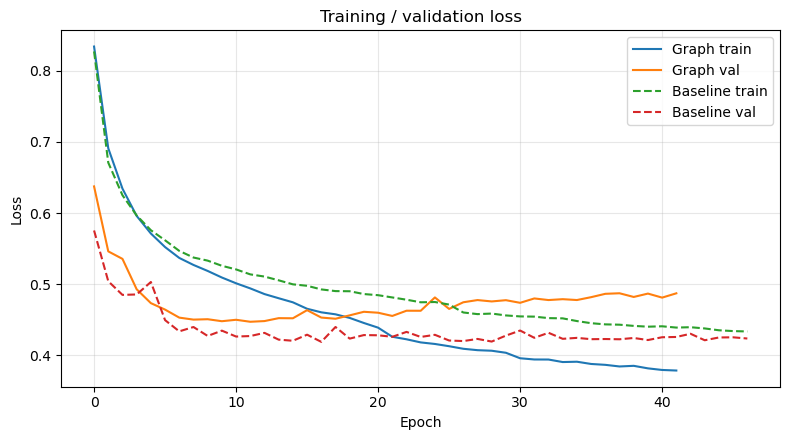

In [271]:
plt.figure(figsize=(8, 4.5))
plt.plot(hist_graph["train_loss"], label="Graph train")
plt.plot(hist_graph["val_loss"], label="Graph val")
plt.plot(hist_base["train_loss"], label="Baseline train", linestyle="--")
plt.plot(hist_base["val_loss"], label="Baseline val", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / validation loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

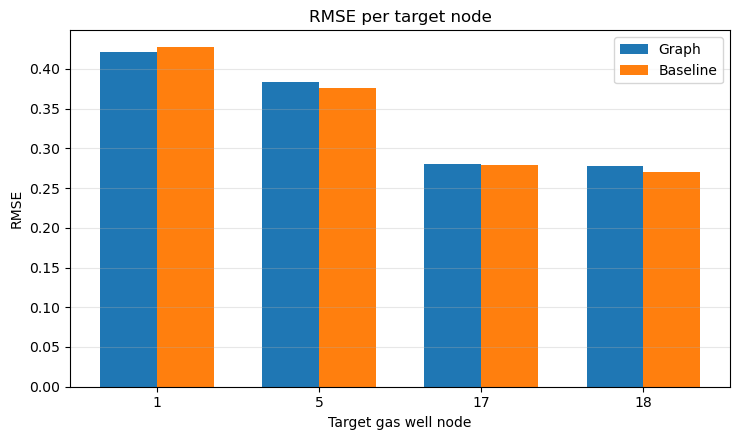

In [272]:
node_labels = [str(n) for n in CFG.target_nodes_1based]
x = np.arange(len(node_labels))
width = 0.35

plt.figure(figsize=(7.5, 4.5))
plt.bar(x - width / 2, metrics_graph["RMSE_per_node"], width=width, label="Graph")
plt.bar(x + width / 2, metrics_base["RMSE_per_node"], width=width, label="Baseline")
plt.xticks(x, node_labels)
plt.xlabel("Target gas well node")
plt.ylabel("RMSE")
plt.title("RMSE per target node")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

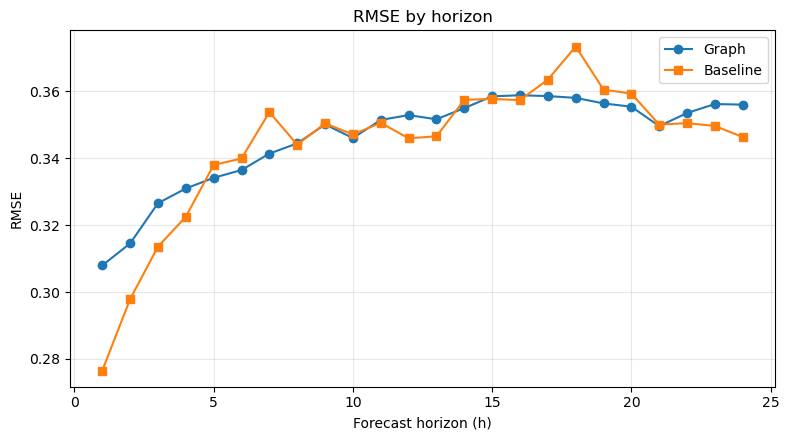

In [273]:
plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(1, CFG.output_len + 1), metrics_graph["RMSE_per_horizon"], marker="o", label="Graph")
plt.plot(np.arange(1, CFG.output_len + 1), metrics_base["RMSE_per_horizon"], marker="s", label="Baseline")
plt.xlabel("Forecast horizon (h)")
plt.ylabel("RMSE")
plt.title("RMSE by horizon")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

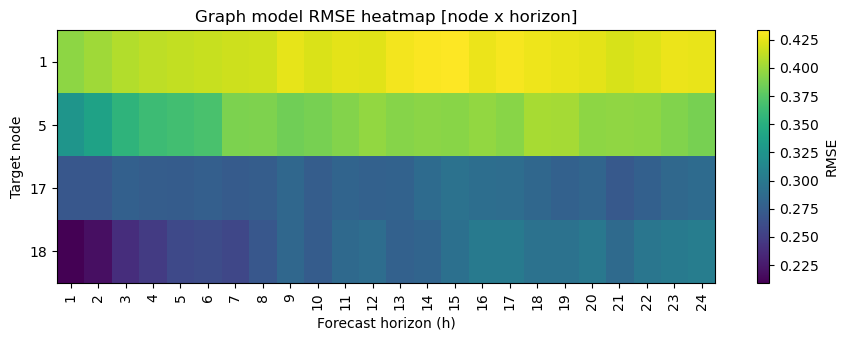

In [274]:
plt.figure(figsize=(9, 3.5))
plt.imshow(metrics_graph["heatmap_rmse"], aspect="auto")
plt.colorbar(label="RMSE")
plt.yticks(np.arange(len(node_labels)), node_labels)
plt.xticks(np.arange(CFG.output_len), np.arange(1, CFG.output_len + 1), rotation=90)
plt.xlabel("Forecast horizon (h)")
plt.ylabel("Target node")
plt.title("Graph model RMSE heatmap [node x horizon]")
plt.tight_layout()
plt.show()

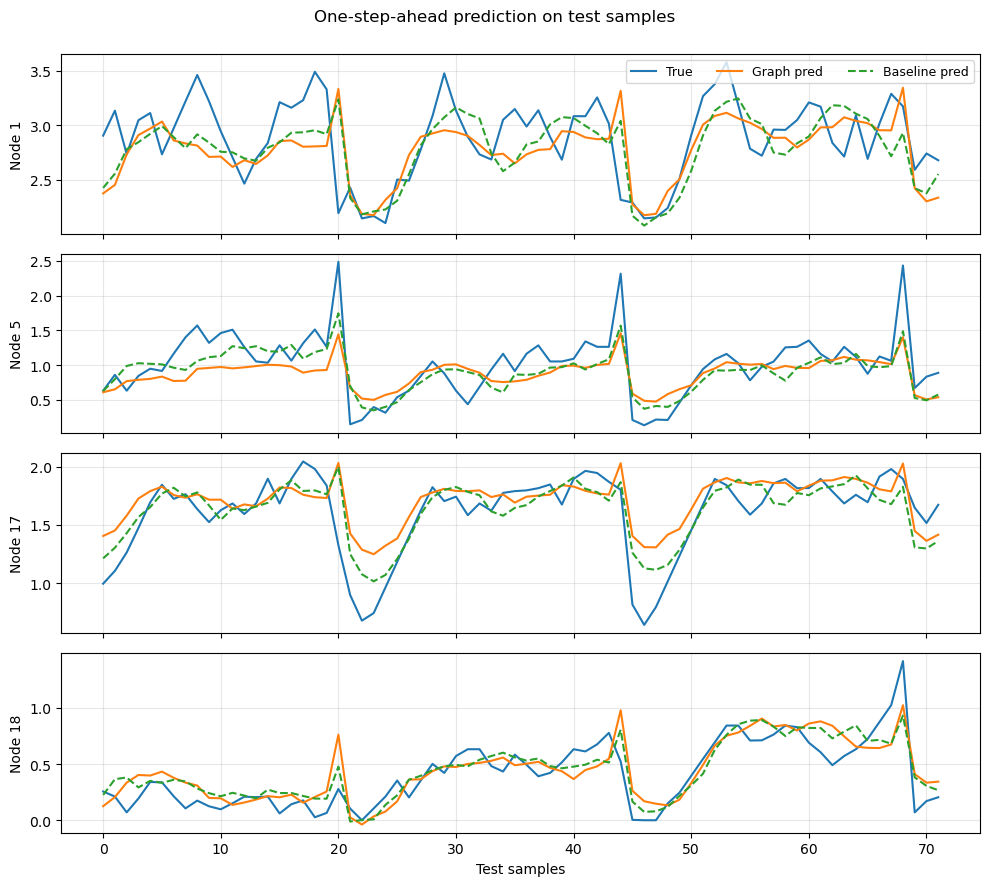

In [275]:
num_plot = min(72, len(graph_pred))
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(graph_true[:num_plot, 0, i], label="True")
    ax.plot(graph_pred[:num_plot, 0, i], label="Graph pred")
    ax.plot(base_pred[:num_plot, 0, i], label="Baseline pred", linestyle="--")
    ax.set_ylabel(f"Node {CFG.target_nodes_1based[i]}")
    ax.grid(alpha=0.3)

axes[0].legend(ncol=3, fontsize=9)
axes[-1].set_xlabel("Test samples")
fig.suptitle("One-step-ahead prediction on test samples")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [276]:
print("Expected shapes:")
print(f"X_all_raw: [T={T}, N={CFG.num_nodes}, F={X_all_raw.shape[-1]}]")
print(f"Y_all_raw: [T={T}, num_targets={Y_all_raw.shape[-1]}]")
print(f"X_seq: [num_samples={len(X_seq)}, Tin={CFG.input_len}, N={CFG.num_nodes}, F={X_seq.shape[-1]}]")
print(f"Y_seq: [num_samples={len(Y_seq)}, Tout={CFG.output_len}, num_targets={Y_seq.shape[-1]}]")

Expected shapes:
X_all_raw: [T=8784, N=28, F=28]
Y_all_raw: [T=8784, num_targets=4]
X_seq: [num_samples=8689, Tin=72, N=28, F=28]
Y_seq: [num_samples=8689, Tout=24, num_targets=4]


In [277]:
print("Dynamic + time + static feature names:")
for i, name in enumerate(feat["feature_names"]):
    print(i, name)

Dynamic + time + static feature names:
0 g_hist
1 ind_global
2 distrib_global
3 export_local
4 ind_roll24
5 distrib_roll24
6 g_lag1
7 g_lag2
8 g_lag3
9 g_lag24
10 hour_norm
11 dow_norm
12 is_peak_hour
13 node_id_norm
14 res_share
15 ind_share
16 exp_share
17 pr_min
18 pr_max
19 degree
20 is_well
21 is_gfpp
22 is_export
23 is_compressor
24 is_source
25 is_load
26 is_internal
27 gmax_norm


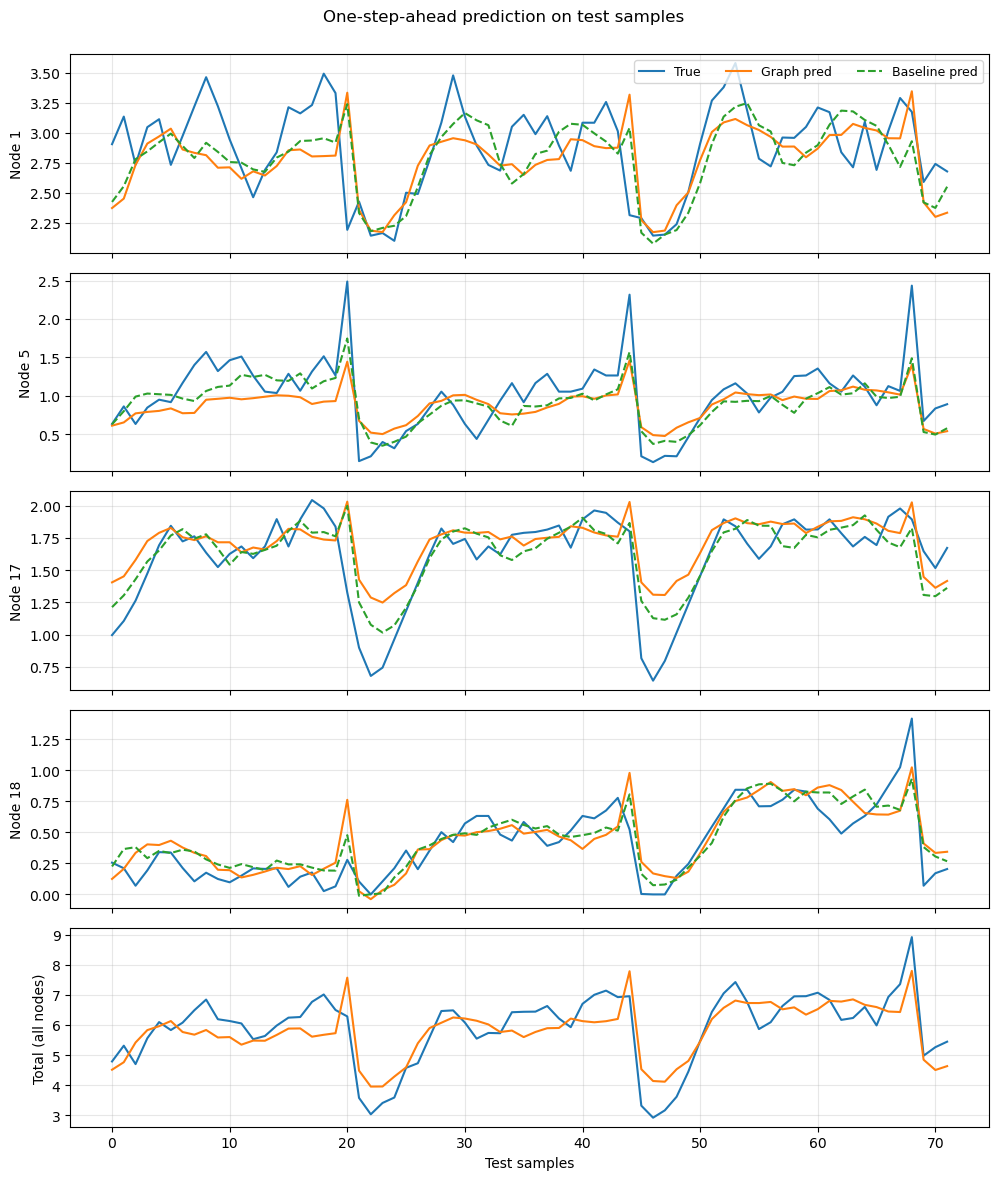

In [278]:
num_plot = min(72, len(graph_pred))

# Calcul du total (somme des 4 nœuds)
graph_true_total = graph_true[:, 0, :].sum(axis=-1)  # [N_samples]
graph_pred_total = graph_pred[:, 0, :].sum(axis=-1)
base_pred_total  = base_pred[:, 0, :].sum(axis=-1)

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)  # 5 subplots au lieu de 4

# Les 4 nœuds individuels
for i, ax in enumerate(axes[:4]):
    ax.plot(graph_true[:num_plot, 0, i], label="True")
    ax.plot(graph_pred[:num_plot, 0, i], label="Graph pred")
    ax.plot(base_pred[:num_plot, 0, i],  label="Baseline pred", linestyle="--")
    ax.set_ylabel(f"Node {CFG.target_nodes_1based[i]}")
    ax.grid(alpha=0.3)

# Total
axes[4].plot(graph_true_total[:num_plot], label="True total")
axes[4].plot(graph_pred_total[:num_plot], label="Graph pred total")

axes[4].set_ylabel("Total (all nodes)")
axes[4].grid(alpha=0.3)

axes[0].legend(ncol=3, fontsize=9)
axes[-1].set_xlabel("Test samples")
fig.suptitle("One-step-ahead prediction on test samples")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [279]:
# ===== GRAPH MODEL =====
mae_graph = np.mean(np.abs(graph_true - graph_pred))
rmse_graph = np.sqrt(np.mean((graph_true - graph_pred) ** 2))
mean_graph = np.mean(graph_true)
mean_abs_graph = np.mean(np.abs(graph_true))

print("=== GRAPH MODEL ===")
print(f"MAE = {mae_graph:.6f}")
print(f"RMSE = {rmse_graph:.6f}")
print(f"mean(true) = {mean_graph:.6f}")
print(f"mean(|true|) = {mean_abs_graph:.6f}")
print(f"MAE / mean(true) = {mae_graph / mean_graph:.6f}")
print(f"MAE / mean(|true|) = {mae_graph / mean_abs_graph:.6f}")
print(f"RMSE / mean(|true|) = {rmse_graph / mean_abs_graph:.6f}")
print(f"MAE / mean(|true|) [%] = {100 * mae_graph / mean_abs_graph:.2f}%")
print(f"RMSE / mean(|true|) [%] = {100 * rmse_graph / mean_abs_graph:.2f}%")

# ===== BASELINE MODEL =====
mae_base = np.mean(np.abs(base_true - base_pred))
rmse_base = np.sqrt(np.mean((base_true - base_pred) ** 2))
mean_base = np.mean(base_true)
mean_abs_base = np.mean(np.abs(base_true))

print("\n=== BASELINE MODEL ===")
print(f"MAE = {mae_base:.6f}")
print(f"RMSE = {rmse_base:.6f}")
print(f"mean(true) = {mean_base:.6f}")
print(f"mean(|true|) = {mean_abs_base:.6f}")
print(f"MAE / mean(true) = {mae_base / mean_base:.6f}")
print(f"MAE / mean(|true|) = {mae_base / mean_abs_base:.6f}")
print(f"RMSE / mean(|true|) = {rmse_base / mean_abs_base:.6f}")
print(f"MAE / mean(|true|) [%] = {100 * mae_base / mean_abs_base:.2f}%")
print(f"RMSE / mean(|true|) [%] = {100 * rmse_base / mean_abs_base:.2f}%")

=== GRAPH MODEL ===
MAE = 0.270003
RMSE = 0.346266
mean(true) = 1.298530
mean(|true|) = 1.298530
MAE / mean(true) = 0.207929
MAE / mean(|true|) = 0.207929
RMSE / mean(|true|) = 0.266660
MAE / mean(|true|) [%] = 20.79%
RMSE / mean(|true|) [%] = 26.67%

=== BASELINE MODEL ===
MAE = 0.270740
RMSE = 0.344474
mean(true) = 1.298530
mean(|true|) = 1.298530
MAE / mean(true) = 0.208497
MAE / mean(|true|) = 0.208497
RMSE / mean(|true|) = 0.265280
MAE / mean(|true|) [%] = 20.85%
RMSE / mean(|true|) [%] = 26.53%


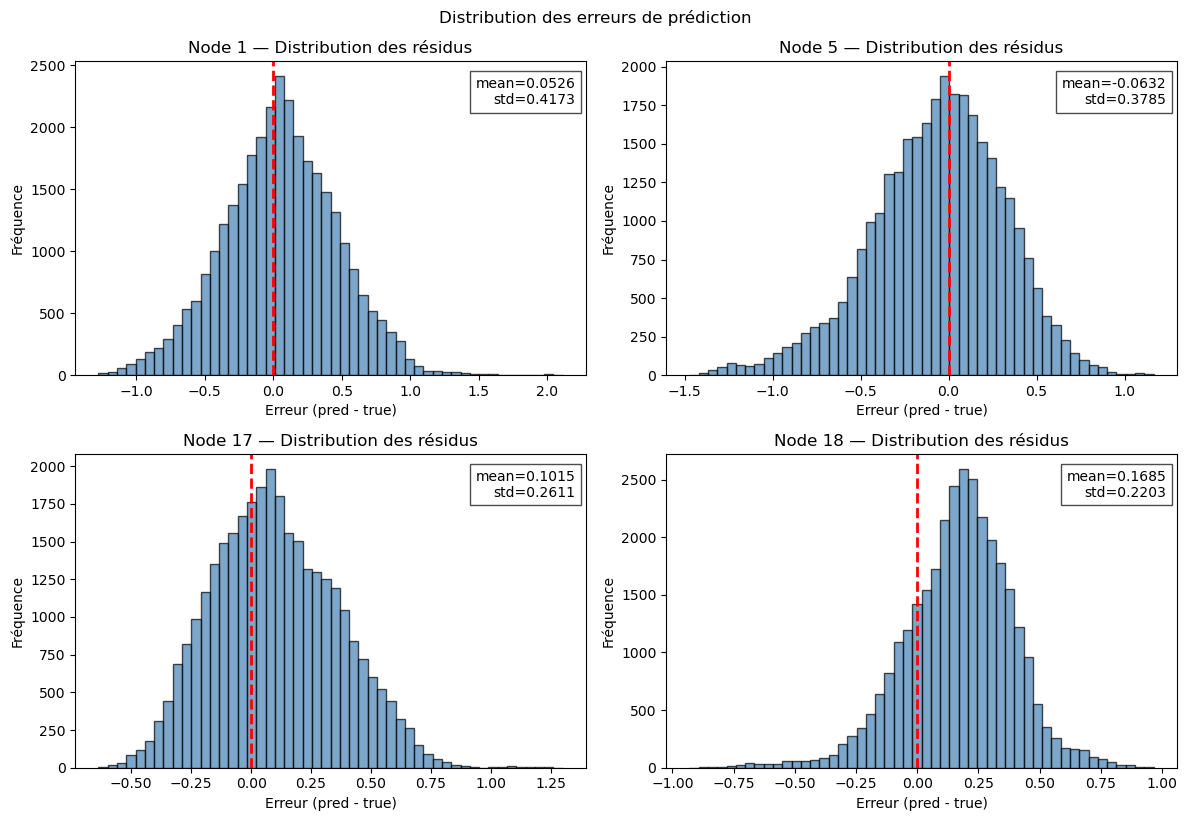

In [280]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
node_names = [f"Node {n}" for n in CFG.target_nodes_1based]

for i, ax in enumerate(axes.flatten()):
    residuals = graph_pred[:, :, i].flatten() - graph_true[:, :, i].flatten()
    
    ax.hist(residuals, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f"{node_names[i]} — Distribution des résidus")
    ax.set_xlabel("Erreur (pred - true)")
    ax.set_ylabel("Fréquence")
    
    # Stats dans le titre
    ax.text(0.98, 0.95, f"mean={residuals.mean():.4f}\nstd={residuals.std():.4f}",
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.suptitle("Distribution des erreurs de prédiction", y=1.02)
plt.show()

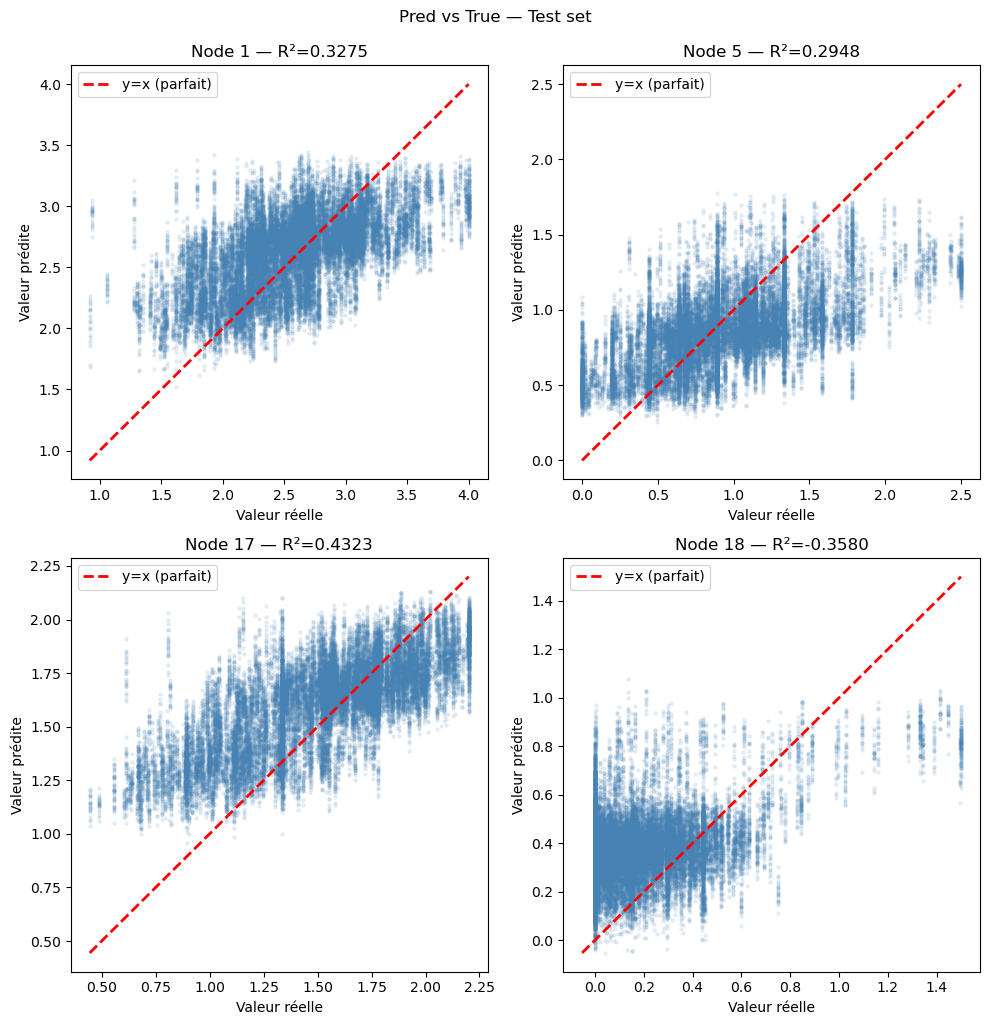

In [281]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    true_flat = graph_true[:, :, i].flatten()
    pred_flat = graph_pred[:, :, i].flatten()
    
    ax.scatter(true_flat, pred_flat, alpha=0.1, s=5, color='steelblue')
    
    # Droite idéale y=x
    lims = [min(true_flat.min(), pred_flat.min()),
            max(true_flat.max(), pred_flat.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='y=x (parfait)')
    
    # R²
    ss_res = np.sum((true_flat - pred_flat) ** 2)
    ss_tot = np.sum((true_flat - true_flat.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    
    ax.set_title(f"Node {CFG.target_nodes_1based[i]} — R²={r2:.4f}")
    ax.set_xlabel("Valeur réelle")
    ax.set_ylabel("Valeur prédite")
    ax.legend()

plt.tight_layout()
plt.suptitle("Pred vs True — Test set", y=1.02)
plt.show()

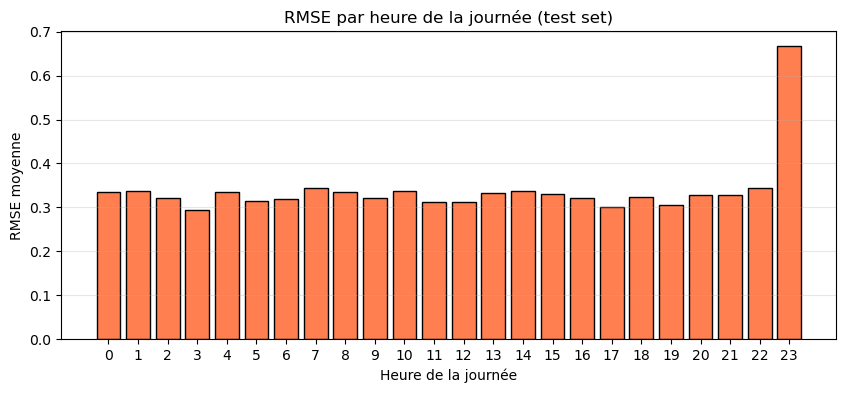

In [282]:
# Identifier quelle heure est la plus difficile à prédire
test_mask = split_labels == "test"
test_dates = date_seq[test_mask]  # shape [N_test, output_len]

hourly_rmse = np.zeros(24)
hourly_count = np.zeros(24)

for s in range(len(graph_pred)):
    for h in range(CFG.output_len):
        hour = pd.Timestamp(test_dates[s, h]).hour
        err_sq = (graph_pred[s, h, :] - graph_true[s, h, :]) ** 2
        hourly_rmse[hour] += err_sq.mean()
        hourly_count[hour] += 1

hourly_rmse = np.sqrt(hourly_rmse / np.maximum(hourly_count, 1))

plt.figure(figsize=(10, 4))
plt.bar(np.arange(24), hourly_rmse, color='coral', edgecolor='black')
plt.xlabel("Heure de la journée")
plt.ylabel("RMSE moyenne")
plt.title("RMSE par heure de la journée (test set)")
plt.xticks(np.arange(24))
plt.grid(axis='y', alpha=0.3)
plt.show()

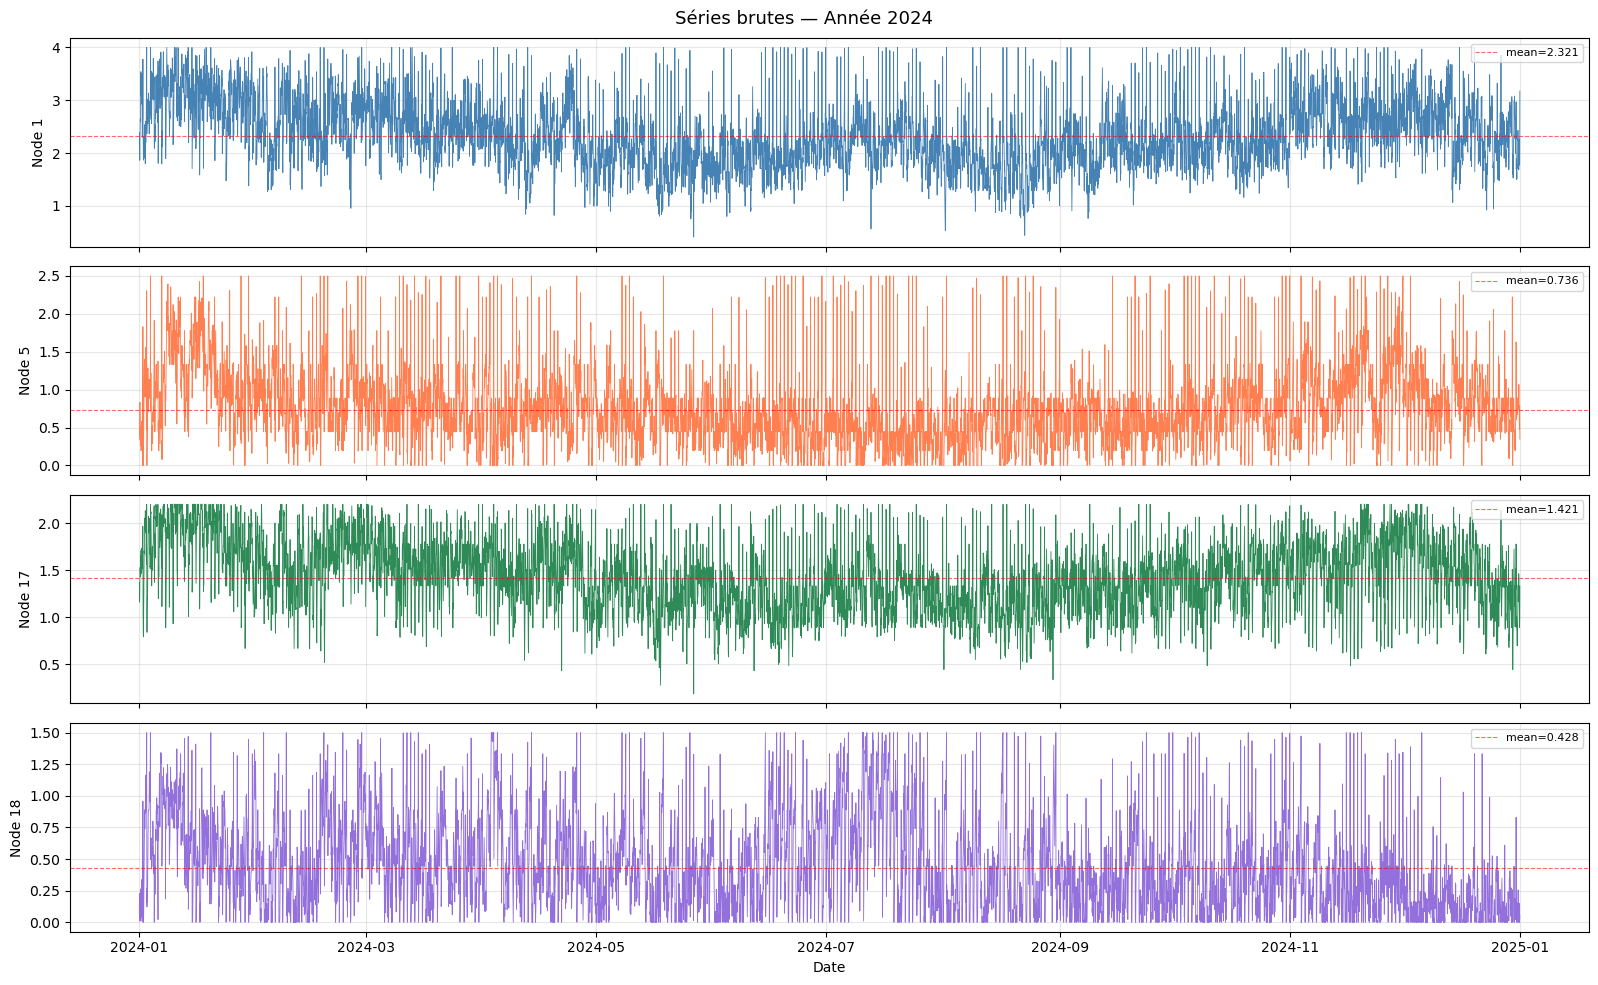

In [283]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

node_names = [f"Node {n}" for n in CFG.target_nodes_1based]
colors     = ["steelblue", "coral", "seagreen", "mediumpurple"]
dt_series  = pd.to_datetime(op["datetime"])

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(dt_series, Y_all_raw[:, i], linewidth=0.6, color=colors[i])
    ax.set_ylabel(node_names[i], fontsize=10)
    ax.grid(alpha=0.3)
    mean_val = Y_all_raw[:, i].mean()
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=0.8,
               alpha=0.6, label=f"mean={mean_val:.3f}")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Date")
fig.suptitle("Séries brutes — Année 2024", fontsize=13)
plt.tight_layout()
plt.show()

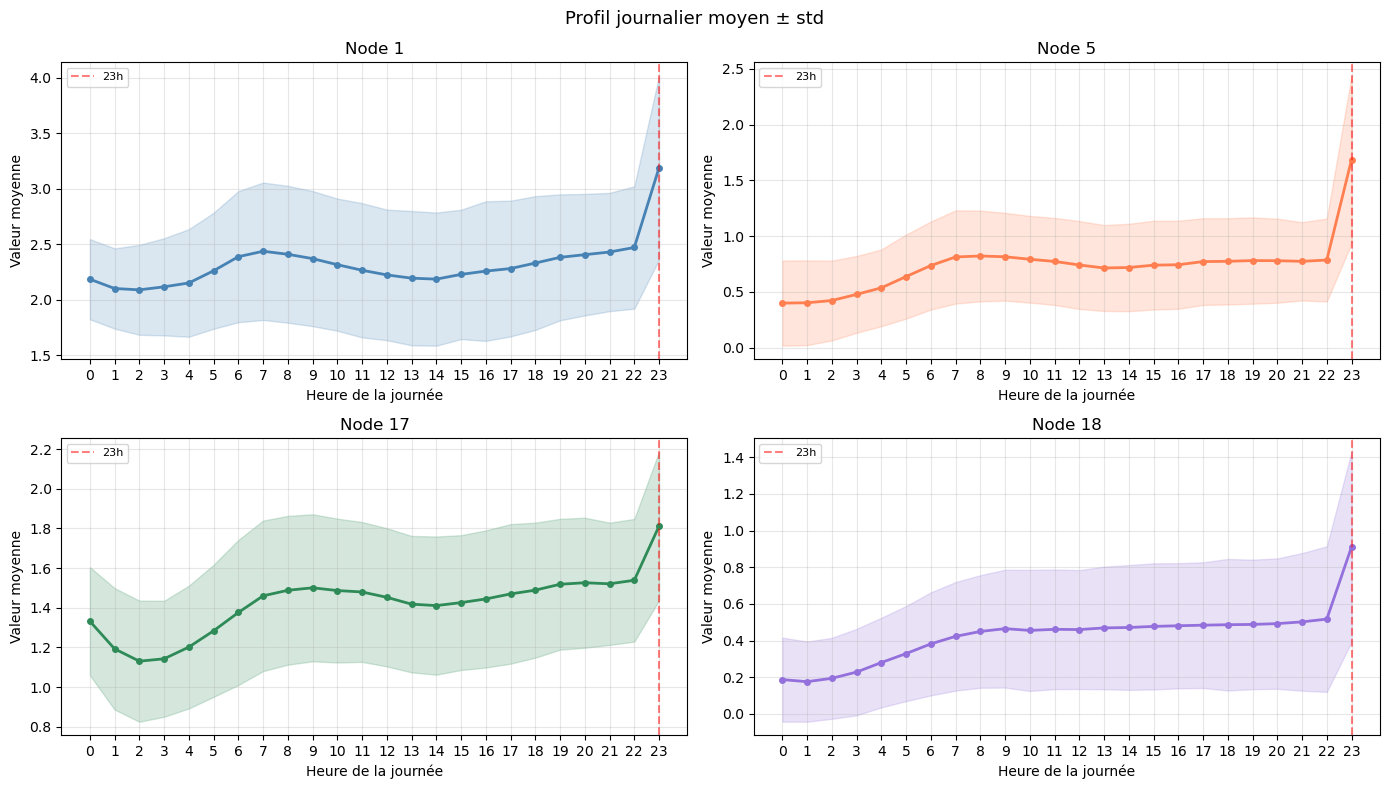

In [284]:
# Réponse à : "est-ce que le pic à 23h est présent toute l'année ?"
df_g = pd.DataFrame(Y_all_raw, columns=node_names)
df_g["datetime"] = dt_series.values
df_g["hour"]     = dt_series.dt.hour.values
df_g["month"]    = dt_series.dt.month.values
df_g["dow"]      = dt_series.dt.dayofweek.values

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    hourly = df_g.groupby("hour")[node_names[i]].agg(["mean", "std"])
    ax.fill_between(hourly.index,
                    hourly["mean"] - hourly["std"],
                    hourly["mean"] + hourly["std"],
                    alpha=0.2, color=colors[i])
    ax.plot(hourly.index, hourly["mean"],
            color=colors[i], linewidth=2, marker="o", markersize=4)
    ax.set_title(node_names[i])
    ax.set_xlabel("Heure de la journée")
    ax.set_ylabel("Valeur moyenne")
    ax.set_xticks(range(24))
    ax.grid(alpha=0.3)
    # Marquer 23h
    ax.axvline(23, color='red', linestyle='--', alpha=0.5, label="23h")
    ax.legend(fontsize=8)

plt.suptitle("Profil journalier moyen ± std", fontsize=13)
plt.tight_layout()
plt.show()

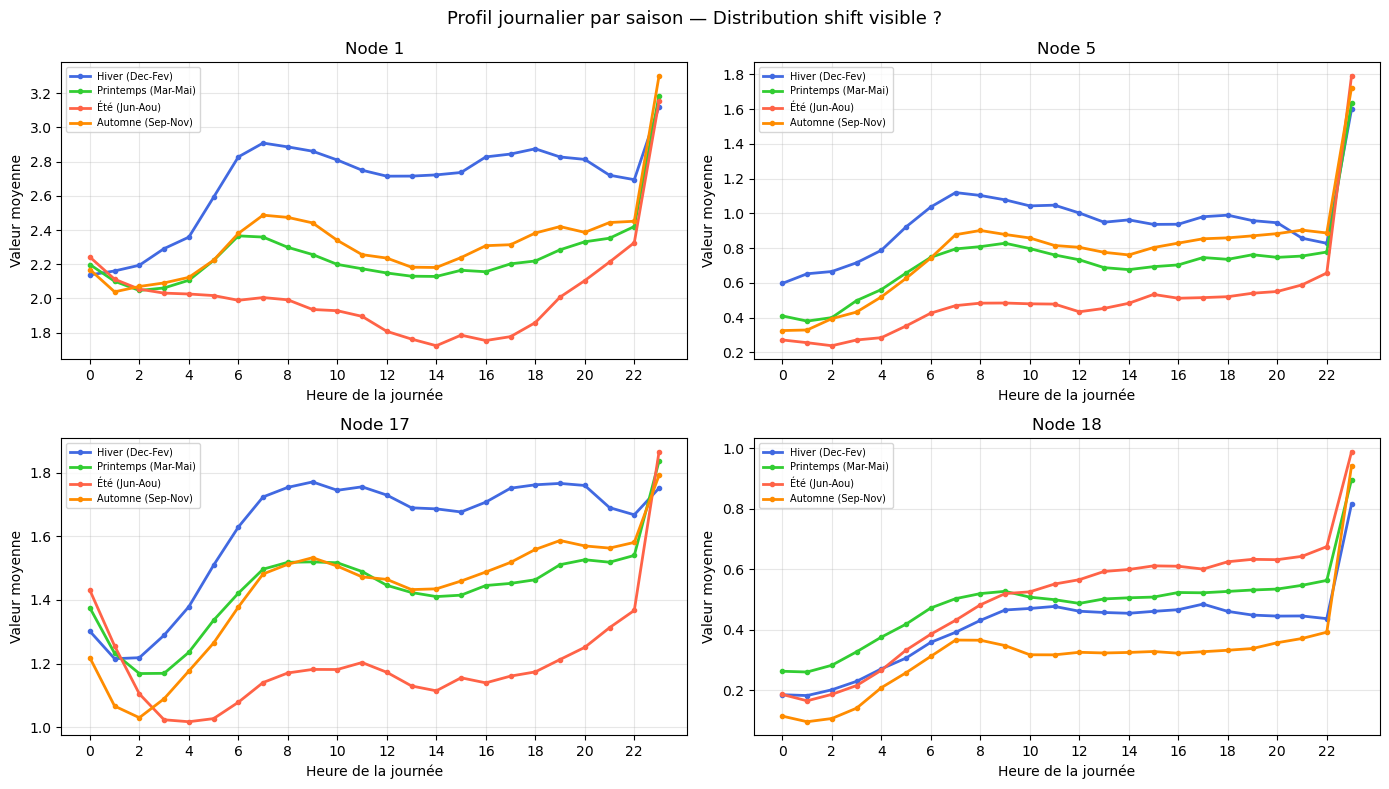


=== MOYENNES PAR SAISON ===
Saison                            Node 1      Node 5     Node 17     Node 18
---------------------------------------------------------------------------
Hiver (Dec-Fev)                   2.6828      0.9461      1.6218      0.4081
Printemps (Mar-Mai)               2.2545      0.7201      1.4359      0.4831
Été (Jun-Aou)                     2.0205      0.5024      1.2027      0.5005
Automne (Sep-Nov)                 2.3307      0.7769      1.4238      0.3175


In [285]:
# Réponse à : "train=été vs val=automne, est-ce que c'est vraiment différent ?"
saisons = {
    "Hiver (Dec-Fev)":   [12, 1, 2],
    "Printemps (Mar-Mai)": [3, 4, 5],
    "Été (Jun-Aou)":     [6, 7, 8],
    "Automne (Sep-Nov)": [9, 10, 11],
}
saison_colors = ["royalblue", "limegreen", "tomato", "darkorange"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    for (saison_name, mois), sc in zip(saisons.items(), saison_colors):
        mask    = df_g["month"].isin(mois)
        hourly  = df_g[mask].groupby("hour")[node_names[i]].mean()
        ax.plot(hourly.index, hourly.values,
                label=saison_name, color=sc, linewidth=2, marker="o", markersize=3)

    ax.set_title(node_names[i])
    ax.set_xlabel("Heure de la journée")
    ax.set_ylabel("Valeur moyenne")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle("Profil journalier par saison — Distribution shift visible ?", fontsize=13)
plt.tight_layout()
plt.show()

# Print des moyennes par saison
print("\n=== MOYENNES PAR SAISON ===")
print(f"{'Saison':<28s}", end="")
for n in node_names:
    print(f"  {n:>10s}", end="")
print()
print("-" * 75)
for saison_name, mois in saisons.items():
    mask = df_g["month"].isin(mois)
    print(f"{saison_name:<28s}", end="")
    for n in node_names:
        print(f"  {df_g[mask][n].mean():>10.4f}", end="")
    print()

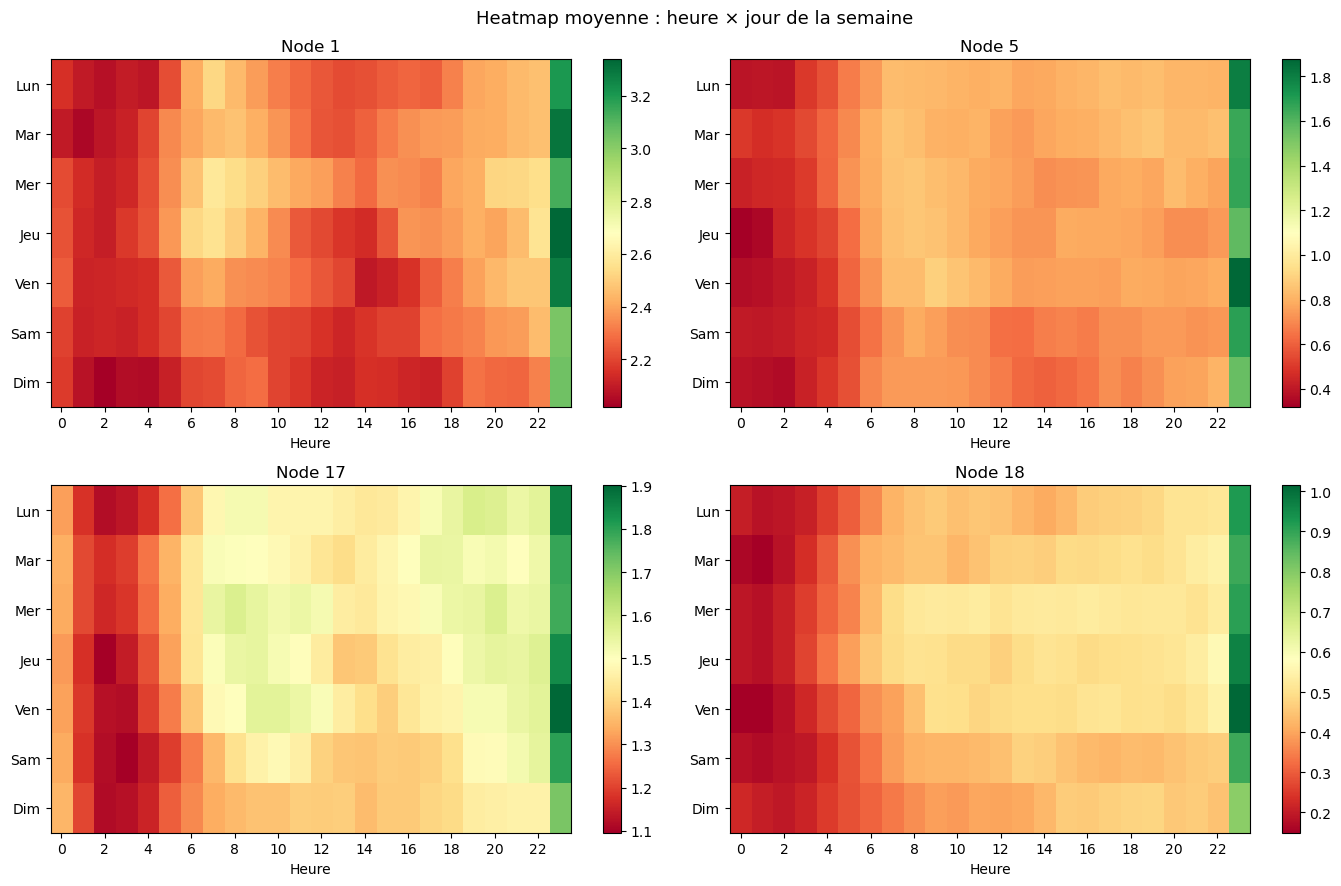

In [286]:
# Réponse à : "y a-t-il un pattern heure+jour combiné ?"
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    pivot = df_g.pivot_table(
        values=node_names[i],
        index="dow",
        columns="hour",
        aggfunc="mean"
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_yticks(range(7))
    ax.set_yticklabels(["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(0, 24, 2))
    ax.set_xlabel("Heure")
    ax.set_title(node_names[i])
    plt.colorbar(im, ax=ax)

plt.suptitle("Heatmap moyenne : heure × jour de la semaine", fontsize=13)
plt.tight_layout()
plt.show()

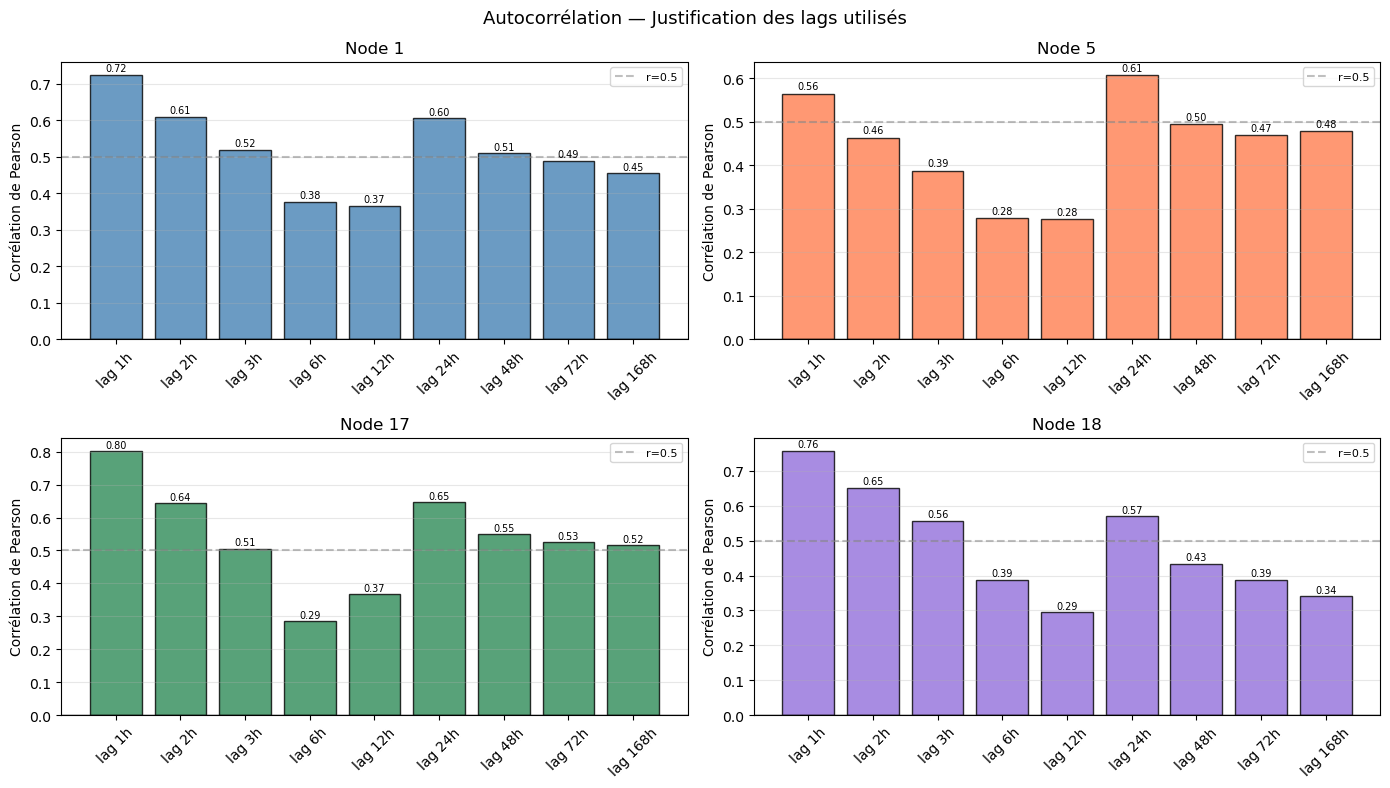

In [287]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

lags_to_check = [1, 2, 3, 6, 12, 24, 48, 72, 168]

for i, ax in enumerate(axes):
    series = pd.Series(Y_all_raw[:, i])
    acf_vals = [series.autocorr(lag=l) for l in lags_to_check]

    bars = ax.bar(range(len(lags_to_check)), acf_vals,
                  color=[colors[i] if v > 0 else "red" for v in acf_vals],
                  edgecolor="black", alpha=0.8)
    ax.set_xticks(range(len(lags_to_check)))
    ax.set_xticklabels([f"lag {l}h" for l in lags_to_check], rotation=45)
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="r=0.5")
    ax.set_title(node_names[i])
    ax.set_ylabel("Corrélation de Pearson")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

    # Annoter les valeurs
    for bar, val in zip(bars, acf_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 if val > 0 else bar.get_height() - 0.04,
                f"{val:.2f}", ha="center", fontsize=7)

plt.suptitle("Autocorrélation — Justification des lags utilisés", fontsize=13)
plt.tight_layout()
plt.show()

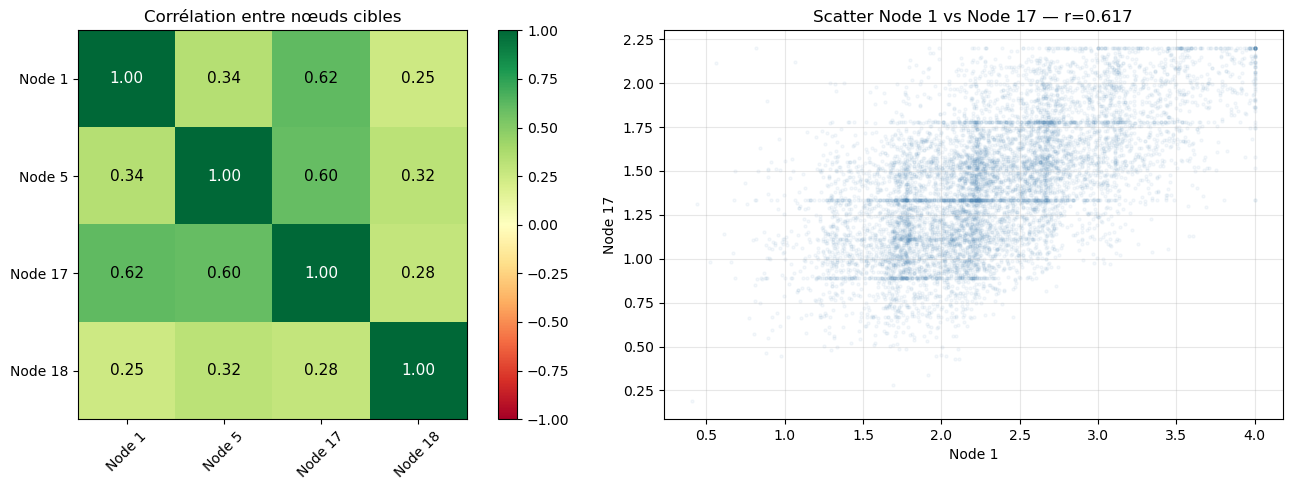

In [288]:
# Réponse à : "est-ce que les 4 nœuds s'influencent vraiment ?"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de corrélation
corr = pd.DataFrame(Y_all_raw, columns=node_names).corr()
im = axes[0].imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(node_names, rotation=45)
axes[0].set_yticklabels(node_names)
plt.colorbar(im, ax=axes[0])
for ii in range(4):
    for jj in range(4):
        axes[0].text(jj, ii, f"{corr.values[ii,jj]:.2f}",
                    ha="center", va="center", fontsize=11,
                    color="black" if abs(corr.values[ii,jj]) < 0.7 else "white")
axes[0].set_title("Corrélation entre nœuds cibles")

# Scatter matrix Node 1 vs Node 17 (les 2 plus corrélés probablement)
axes[1].scatter(Y_all_raw[:, 0], Y_all_raw[:, 2],
               alpha=0.05, s=5, color="steelblue")
axes[1].set_xlabel(node_names[0])
axes[1].set_ylabel(node_names[2])
r = np.corrcoef(Y_all_raw[:, 0], Y_all_raw[:, 2])[0, 1]
axes[1].set_title(f"Scatter {node_names[0]} vs {node_names[2]} — r={r:.3f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

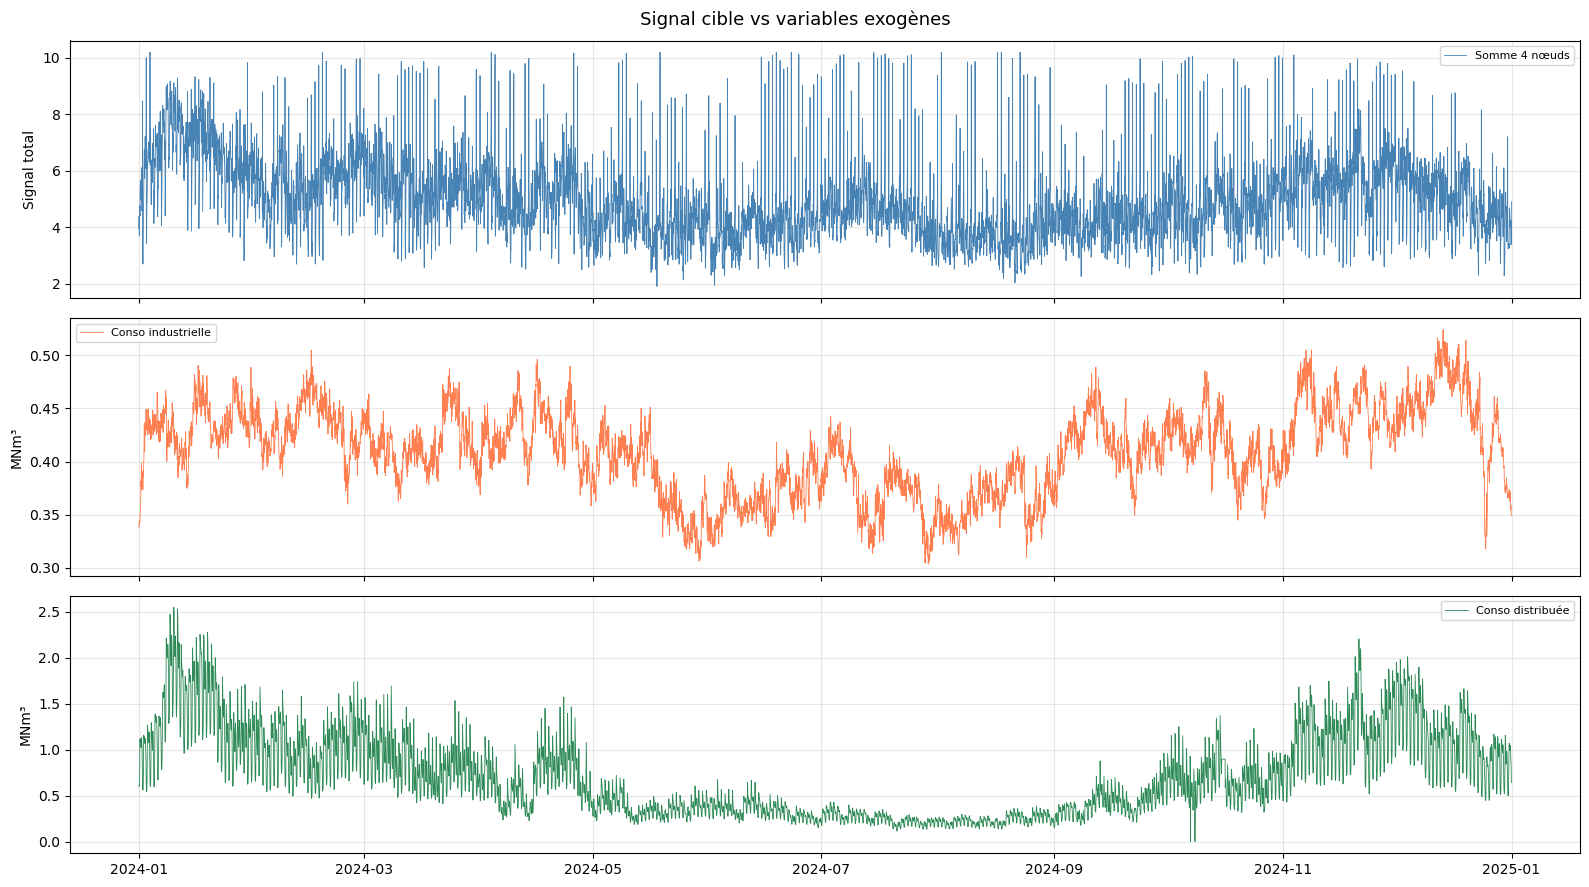


Corrélation conso industrielle → signal total : 0.3587
Corrélation conso distribuée  → signal total : 0.6080


In [289]:
# Réponse à : "les variables exogènes expliquent-elles le signal ?"
ind_global     = exo["ind_df"]["Physical Flow (MNm3)"].to_numpy()
distrib_global = exo["distrib_df"]["Physical Flow (MNm3)"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

ax = axes[0]
ax.plot(dt_series, Y_all_raw.sum(axis=1), color="steelblue",
        linewidth=0.6, label="Somme 4 nœuds")
ax.set_ylabel("Signal total")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(dt_series, ind_global, color="coral",
        linewidth=0.6, label="Conso industrielle")
ax.set_ylabel("MNm³")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(dt_series, distrib_global, color="seagreen",
        linewidth=0.6, label="Conso distribuée")
ax.set_ylabel("MNm³")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle("Signal cible vs variables exogènes", fontsize=13)
plt.tight_layout()
plt.show()

# Corrélations exogènes → signal
total = Y_all_raw.sum(axis=1)
r_ind     = np.corrcoef(ind_global, total)[0, 1]
r_distrib = np.corrcoef(distrib_global, total)[0, 1]
print(f"\nCorrélation conso industrielle → signal total : {r_ind:.4f}")
print(f"Corrélation conso distribuée  → signal total : {r_distrib:.4f}")


 GNN (Context-Gated) — Métriques sur total agrégé (4 nœuds)
  MAE  total        = 0.6700
  RMSE total        = 0.8556
  mean(|total|)     = 5.1941
  MAE  / mean [%]   = 12.90%
  RMSE / mean [%]   = 16.47%
  R²   total        = 0.4918

  MAE/MEAN par horizon :
    h+01 : 11.47%  █████
    h+02 : 11.49%  █████
    h+03 : 12.04%  ██████
    h+04 : 12.17%  ██████
    h+05 : 12.08%  ██████
    h+06 : 12.14%  ██████
    h+07 : 12.02%  ██████
    h+08 : 12.16%  ██████
    h+09 : 13.18%  ██████
    h+10 : 12.50%  ██████
    h+11 : 13.05%  ██████
    h+12 : 13.07%  ██████
    h+13 : 13.17%  ██████
    h+14 : 13.66%  ██████
    h+15 : 13.92%  ██████
    h+16 : 13.78%  ██████
    h+17 : 13.80%  ██████
    h+18 : 13.72%  ██████
    h+19 : 13.47%  ██████
    h+20 : 13.48%  ██████
    h+21 : 12.82%  ██████
    h+22 : 13.22%  ██████
    h+23 : 13.62%  ██████
    h+24 : 13.56%  ██████

 Baseline MLP — Métriques sur total agrégé (4 nœuds)
  MAE  total        = 0.7151
  RMSE total        = 0.9022
  mea

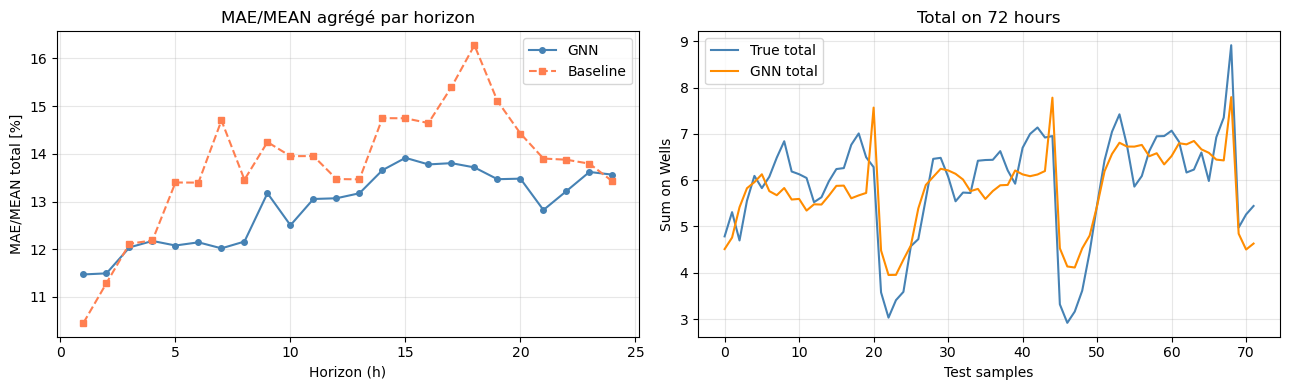

In [290]:
# ── MAE/MEAN sur les totaux agrégés (somme des 4 nœuds) ──────────────────────

def compute_aggregate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calcule les métriques sur le total agrégé des 4 nœuds.
    y_true, y_pred : [N_samples, output_len, 4]
    
    Le total agrégé est la somme des 4 nœuds à chaque pas de temps.
    C'est souvent la grandeur opérationnelle la plus importante :
    on veut que la somme soit juste même si les nœuds individuels varient.
    """
    # Somme sur les 4 nœuds → [N_samples, output_len]
    total_true = y_true.sum(axis=-1)
    total_pred = y_pred.sum(axis=-1)

    err        = total_pred - total_true
    mae_total  = np.mean(np.abs(err))
    rmse_total = np.sqrt(np.mean(err ** 2))
    mean_total = np.mean(np.abs(total_true))

    mae_over_mean  = mae_total  / mean_total * 100
    rmse_over_mean = rmse_total / mean_total * 100

    # MAE/MEAN par horizon (sur le total)
    mae_per_horizon  = np.mean(np.abs(err), axis=0)          # [output_len]
    mean_per_horizon = np.mean(np.abs(total_true), axis=0)   # [output_len]
    mae_norm_horizon = mae_per_horizon / mean_per_horizon * 100

    # R² sur le total
    ss_res = np.sum((total_true - total_pred) ** 2)
    ss_tot = np.sum((total_true - total_true.mean()) ** 2)
    r2_total = 1 - ss_res / ss_tot

    print(f"\n{'='*55}")
    print(f" {model_name} — Métriques sur total agrégé (4 nœuds)")
    print(f"{'='*55}")
    print(f"  MAE  total        = {mae_total:.4f}")
    print(f"  RMSE total        = {rmse_total:.4f}")
    print(f"  mean(|total|)     = {mean_total:.4f}")
    print(f"  MAE  / mean [%]   = {mae_over_mean:.2f}%")
    print(f"  RMSE / mean [%]   = {rmse_over_mean:.2f}%")
    print(f"  R²   total        = {r2_total:.4f}")
    print(f"\n  MAE/MEAN par horizon :")
    for h in range(len(mae_norm_horizon)):
        bar = "█" * int(mae_norm_horizon[h] / 2)
        print(f"    h+{h+1:02d} : {mae_norm_horizon[h]:5.2f}%  {bar}")

    return {
        "MAE_total":        float(mae_total),
        "RMSE_total":       float(rmse_total),
        "MAE/MEAN_total":   float(mae_over_mean),
        "RMSE/MEAN_total":  float(rmse_over_mean),
        "R2_total":         float(r2_total),
        "MAE/MEAN_horizon": mae_norm_horizon.tolist(),
    }


metrics_agg_graph = compute_aggregate_metrics(
    graph_true, graph_pred, model_name="GNN (Context-Gated)")

metrics_agg_base = compute_aggregate_metrics(
    base_true, base_pred, model_name="Baseline MLP")

# Comparaison directe
print(f"\n{'─'*40}")
print(f" Comparaison MAE/MEAN total agrégé")
print(f"{'─'*40}")
print(f"  GNN      : {metrics_agg_graph['MAE/MEAN_total']:.2f}%")
print(f"  Baseline : {metrics_agg_base['MAE/MEAN_total']:.2f}%")
delta = metrics_agg_graph['MAE/MEAN_total'] - metrics_agg_base['MAE/MEAN_total']
sign  = "+" if delta > 0 else ""
print(f"  Écart    : {sign}{delta:.2f}pp  "
      f"({'GNN pire' if delta > 0 else 'GNN meilleur'})")

# Plot MAE/MEAN par horizon pour les deux modèles
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

horizons = np.arange(1, CFG.output_len + 1)

ax = axes[0]
ax.plot(horizons, metrics_agg_graph["MAE/MEAN_horizon"],
        marker="o", color="steelblue", label="GNN", markersize=4)
ax.plot(horizons, metrics_agg_base["MAE/MEAN_horizon"],
        marker="s", color="coral", linestyle="--", label="Baseline", markersize=4)
ax.set_xlabel("Horizon (h)")
ax.set_ylabel("MAE/MEAN total [%]")
ax.set_title("MAE/MEAN agrégé par horizon")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
total_true_plot = graph_true[:72].sum(axis=-1)[:, 0]
total_pred_plot = graph_pred[:72].sum(axis=-1)[:, 0]
total_base_plot = base_pred[:72].sum(axis=-1)[:, 0]
ax.plot(total_true_plot, color="steelblue",  linewidth=1.5, label="True total")
ax.plot(total_pred_plot, color="darkorange", linewidth=1.5, label="GNN total")
ax.set_xlabel("Test samples")
ax.set_ylabel("Sum on Wells")
ax.set_title("Total on 72 hours")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()